In [ ]:
! uv pip install seaborn morethemes pyfonts pypalettes drawarrow contextily geopandas

Using Python 3.13.9 environment at: C:\Users\Asus\Documents\14_PrixChangementClimatique\.venv
Audited 10 packages in 120ms


# IMPORT


In [161]:
import duckdb

# The usual suspects
import numpy as np
import pandas as pd

# Chart and Figure
import seaborn as sns
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.colors import LinearSegmentedColormap

# Fonts, Palettes, Themes, Arrow (https://github.com/y-sunflower)
# Strong inspiration: https://www.yan-holtz.com/
import morethemes as mt
from pyfonts import load_google_font, load_font
from pypalettes import load_palette, load_cmap
from drawarrow import fig_arrow

# PySAL
import libpysal
from esda.moran import Moran_Local, Moran_Local_BV
from splot.esda import moran_scatterplot, lisa_cluster

# GeoSpatial
import contextily as ctx
from shapely.affinity import translate, scale
import geopandas as gpd

# Removing warnings
import warnings

warnings.filterwarnings("ignore")

# LOAD DATA


In [5]:
# Setup
font = load_google_font(
    "Montserrat", italic=False
)  # check here: https://fonts.google.com/
# mt.set_theme("nature")

source_text = (
    "Source: CCR (Caisse Centrale de Réassurance)"  # Main Source for the analysis
)

In [6]:
communes_geojson_url = "https://raw.githubusercontent.com/gregoiredavid/france-geojson/master/communes-avec-outre-mer.geojson"
communes_geo = gpd.read_file(communes_geojson_url)

In [7]:
con = duckdb.connect(database="dev.duckdb", read_only=True)

In [8]:
query_ccr_main = """
SELECT
	*
FROM dev.main.ccr_main_page
"""

ccr_main = con.sql(query_ccr_main)
ccr_main_df = ccr_main.df()
ccr_main_df.head(2)

,nom_peril,date_arrete,date_parution_jo,code_nor,code_arrete
0,"Inondations et/ou Coulées de Boue, Inondations...",2026-01-19,2026-01-24,INTE2601369A,904
1,Sécheresse,2025-12-12,2025-12-13,INTE2534330A,903


In [9]:
query_ccr_details = """
					SELECT
						*
					FROM dev.main.ccr_details
					"""

ccr_details = con.sql(query_ccr_details)
ccr_details_df = ccr_details.df()
ccr_details_df = ccr_details_df[
    ~ccr_details_df.duplicated(subset=["code_geo", "code_arrete"])
]
ccr_details_df.head(2)

,code_geo,nom_commune,date_debut_evenement,date_fin_evenement,date_arrete,date_parution_jo,nom_peril,franchise,libelle_avis,code_arrete
0,07005,ALBA LA ROMAINE,2025-11-16,2025-11-16,2026-01-19,2026-01-24,Inondations et/ou Coulées de Boue,-,Non reconnue,904
1,07022,BAIX,2025-11-16,2025-11-17,2026-01-19,2026-01-24,Inondations et/ou Coulées de Boue,Simple,Reconnue,904


# GRAPHS


In [10]:
main_data_occur_total = ccr_main_df.groupby("date_arrete").size()

ccr_main_df["nom_peril"] = (
    ccr_main_df["nom_peril"]
    .mask(ccr_main_df["nom_peril"].str.contains("Inondations"), "Inondations")
    .where(ccr_main_df["nom_peril"].str.contains("Inondations|Sécheresse"), "Autre")
)

main_data_occur_inond = (
    ccr_main_df[ccr_main_df["nom_peril"] == "Inondations"].groupby("date_arrete").size()
)
main_data_occur_secheresse = (
    ccr_main_df[ccr_main_df["nom_peril"] == "Sécheresse"].groupby("date_arrete").size()
)

In [11]:
details_par_catnat = ccr_details_df.copy()

details_par_catnat = details_par_catnat.drop_duplicates(
    subset=["code_geo", "code_arrete", "nom_peril"]
)
details_par_catnat["date_arrete"] = pd.to_datetime(details_par_catnat["date_arrete"])
details_par_catnat["libelle_avis"] = details_par_catnat["libelle_avis"].replace(
    {"Reconnue(sans impact sur la modulation)": "Reconnue"}
)

details_par_catnat["nom_peril"] = (
    details_par_catnat["nom_peril"]
    .mask(details_par_catnat["nom_peril"].str.contains("Inondations"), "Inondations")
    .where(
        details_par_catnat["nom_peril"].str.contains("Inondations|Sécheresse"), "Autre"
    )
)

details_par_catnat = details_par_catnat[
    (details_par_catnat["date_arrete"].dt.year > 1983)
    & (details_par_catnat["date_arrete"].dt.year < 2026)
]
details_par_catnat["periode_2010"] = np.where(
    details_par_catnat["date_arrete"].dt.year < 2010, "Avant 2010", "Après 2010"
)

avis_par_catnat = (
    details_par_catnat.groupby(
        [
            pd.Grouper(key="date_arrete", freq="YE"),
            "nom_peril",
            "libelle_avis",
            "periode_2010",
        ]
    )
    .size()
    .reset_index(name="count")
)

## STRIP CATNAT


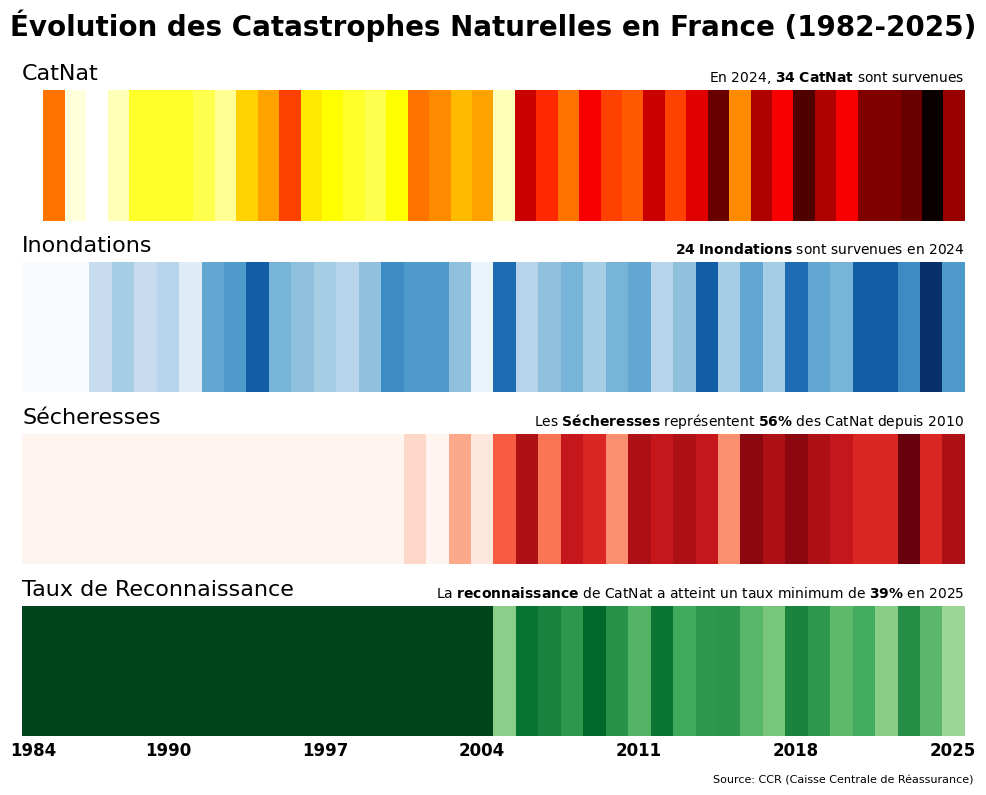

In [12]:
annual_counts = main_data_occur_total.loc[:"2025"].resample("YE").sum()
annual_counts_inond = main_data_occur_inond.loc[:"2025"].resample("YE").sum()
annual_counts_secheresse = main_data_occur_secheresse.loc[:"2025"].resample("YE").sum()

# Recon
recon = details_par_catnat.copy()
recon = (
    (
        recon.groupby([details_par_catnat["date_arrete"], "libelle_avis"])
        .size()
        .unstack(fill_value=0)
    )
    .loc[:"2025"]
    .resample("YE")
    .sum()
)

recon["ratio_recon"] = (recon["Reconnue"] / recon.sum(axis=1)) * 100

all_years = recon.index

data_total = annual_counts.values.reshape(1, -1)
data_inond = annual_counts_inond.reindex(all_years, fill_value=0).values.reshape(1, -1)
data_sech = annual_counts_secheresse.reindex(all_years, fill_value=0).values.reshape(
    1, -1
)
data_recon = recon["ratio_recon"].loc[:"2025"].values.reshape(1, -1)


fig, axs = plt.subplots(nrows=4, figsize=(10, 8))

# CatNat
img = axs[0].imshow(data_total, cmap="hot_r", aspect="auto", interpolation="nearest")
axs[0].set_axis_off()

axs[0].set_title("CatNat", loc="left", pad=7.5, fontsize=16, color="black")

# Inondations
img = axs[1].imshow(data_inond, cmap="Blues", aspect="auto", interpolation="nearest")
axs[1].set_axis_off()

axs[1].set_title("Inondations", loc="left", pad=7.5, fontsize=16, color="black")

# Sécheresse
img = axs[2].imshow(data_sech, cmap="Reds", aspect="auto", interpolation="nearest")
axs[2].set_axis_off()

axs[2].set_title("Sécheresses", loc="left", pad=7.5, fontsize=16, color="black")

# Recon
img = axs[3].imshow(
    data_recon, cmap="Greens", aspect="auto", interpolation="nearest", vmin=0, vmax=100
)

axs[3].set_title(
    "Taux de Reconnaissance", loc="left", pad=7.5, fontsize=16, color="black"
)

# Axis
tick_indices = np.linspace(0, len(all_years) - 1, 7, dtype=int)

axs[3].set_xticks(tick_indices)
axs[3].set_xticklabels(
    [all_years.year[i] for i in tick_indices],
    fontsize=12,
    fontweight="bold",
    color="black",
)

axs[3].tick_params(axis="x", which="both", length=0)

for ax in axs:
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_yticks([])

# Titles and  Annotations
plt.suptitle(
    "Évolution des Catastrophes Naturelles en France (1982-2025)",
    color="black",
    fontsize=20,
    fontweight="bold",
    y=0.99,
)

axs[0].text(
    1,
    1.1,
    r"En 2024, $\bf{34}$ $\bf{CatNat}$ sont survenues",
    transform=axs[0].transAxes,
    ha="right",
    va="center",
    fontsize=10,
    color="black",
)

axs[1].text(
    1,
    1.1,
    r"$\bf{24}$ $\bf{Inondations}$ sont survenues en 2024",
    transform=axs[1].transAxes,
    ha="right",
    va="center",
    fontsize=10,
    color="black",
)

axs[2].text(
    1,
    1.1,
    r"Les $\bf{Sécheresses}$ représentent $\bf{56\%}$ des CatNat depuis 2010",
    transform=axs[2].transAxes,
    ha="right",
    va="center",
    fontsize=10,
    color="black",
)

axs[3].text(
    1,
    1.1,
    r"La $\bf{reconnaissance}$ de CatNat a atteint un taux minimum de $\bf{39\%}$ en 2025",
    transform=axs[3].transAxes,
    ha="right",
    va="center",
    fontsize=10,
    color="black",
)

plt.text(
    1.01,
    -0.375,
    source_text,
    ha="right",
    va="bottom",
    transform=axs[3].transAxes,
    fontsize=8,
    color="black",
)

plt.tight_layout()
"""
plt.savefig(
    "Evolution_CatNat_France_1982_2025.png",
    dpi=300,
    facecolor=fig.get_facecolor(),
    edgecolor="none",
    bbox_inches="tight",
    pad_inches=0.5,
)
"""

plt.show()


## STACKED AREA


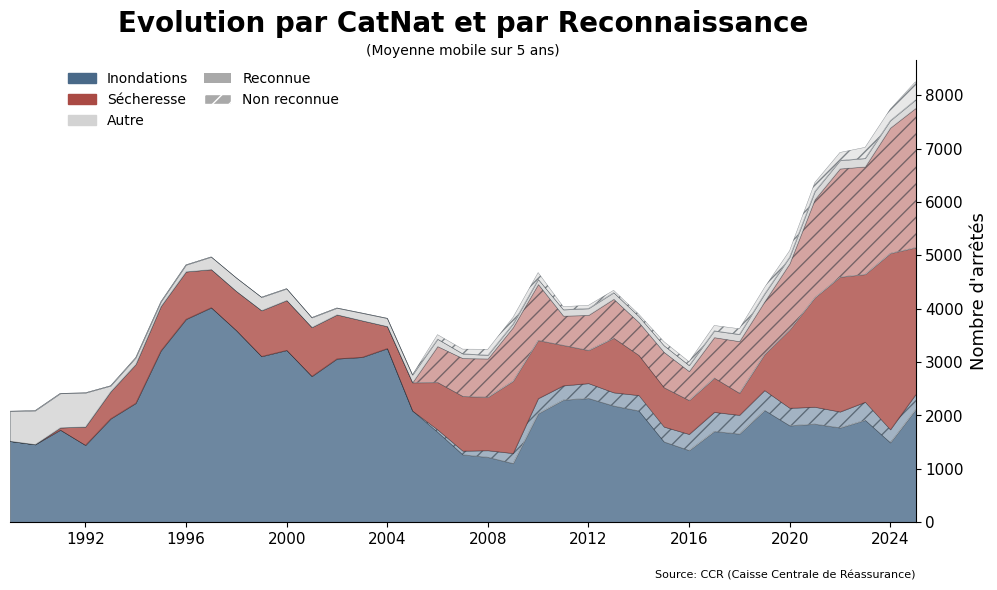

In [13]:
def stacked_area_type_catnat(
    df,
    font=None,
    target_col="libelle_avis",
    hatch="//",
    limit_years=[1984, 2025],
    window=3,
):

    df_plot = df.copy()
    if target_col == "libelle_avis":
        title = "Evolution par CatNat et par Reconnaissance"
        status_request = "Non reconnue"

        custom_order = [
            "Reconnue,Inondations",
            "Non reconnue,Inondations",
            "Reconnue,Sécheresse",
            "Non reconnue,Sécheresse",
            "Reconnue,Autre",
            "Non reconnue,Autre",
        ]
    else:
        df_plot["franchise"] = np.where(
            df_plot["franchise"] == "Simple", "Simple", "Doublée ou plus"
        )
        title = "Evolution par CatNat et par Franchise"
        status_request = "Doublée ou plus"

        custom_order = [
            "Simple,Inondations",
            "Doublée ou plus,Inondations",
            "Simple,Sécheresse",
            "Doublée ou plus,Sécheresse",
            "Simple,Autre",
            "Doublée ou plus,Autre",
        ]

    df_plot = df.pivot_table(
        index="date_arrete",
        columns=[target_col, "nom_peril"],
        values="count",
        aggfunc="sum",
    ).fillna(0)

    df_plot = df_plot.rolling(window=window, center=False).mean()

    new_columns = [(c.split(",")[0], c.split(",")[1]) for c in custom_order]
    df_plot = df_plot[new_columns]

    _, ax = plt.subplots(figsize=(10, 6))

    x = df_plot.index
    y_values = [df_plot[col] for col in df_plot.columns]
    labels = [f"{p} ({s})" for s, p in df_plot.columns]

    layers = ax.stackplot(
        x,
        y_values,
        labels=labels,
        alpha=0.8,
        colors=["#496988", "#496988", "#AA4A44", "#AA4A44", "lightgrey", "lightgrey"],
        edgecolor="#19242E",
        linewidth=0.3,
    )

    for i, (status, peril) in enumerate(df_plot.columns):
        if status == status_request:
            layers[i].set_hatch(hatch)
            layers[i].set_alpha(0.5)

    peril_handles = [
        mpatches.Patch(color="#496988", label="Inondations"),
        mpatches.Patch(color="#AA4A44", label="Sécheresse"),
        mpatches.Patch(color="lightgrey", label="Autre"),
    ]

    status_handles = [
        mpatches.Patch(
            facecolor="darkgrey",
            label="Reconnue" if target_col == "libelle_avis" else "Simple",
        ),
        mpatches.Patch(
            facecolor="darkgrey",
            hatch=hatch,
            edgecolor="white",
            label="Non reconnue" if target_col == "libelle_avis" else "Doublée ou plus",
        ),
    ]

    legend_peril = ax.legend(
        handles=peril_handles,
        loc="upper left",
        bbox_to_anchor=(0.05, 1),
        title="",
        prop=font,
        fontsize=10,
        labelcolor="black",
        frameon=False,
    )
    ax.add_artist(legend_peril)

    ax.legend(
        handles=status_handles,
        loc="upper left",
        bbox_to_anchor=(0.2, 1),
        title="",
        prop=font,
        fontsize=10,
        labelcolor="black",
        frameon=False,
    )
    ax.grid(False)

    plt.title(title, font=font, fontsize=20, fontweight="bold", color="black", pad=20)
    plt.text(
        0.5,
        1.01,
        f"(Moyenne mobile sur {window} ans)",
        font=font,
        fontsize=10,
        color="black",
        ha="center",
        transform=ax.transAxes,
    )

    ax.yaxis.set_ticks_position("right")
    ax.yaxis.set_label_position("right")

    ax.set_ylabel("Nombre d'arrêtés", font=font, fontsize=13, color="black")
    ax.spines["right"].set_visible(True)
    ax.spines["top"].set_visible(False)
    ax.spines["left"].set_visible(False)

    ax.yaxis.set_label_coords(1.06, 0.5)

    plt.yticks(font=font, fontsize=11)
    plt.xticks(font=font, fontsize=11)

    plt.text(
        1,
        -0.125,
        source_text,
        ha="right",
        va="bottom",
        transform=ax.transAxes,
        fontsize=8,
        color="black",
        font=font,
    )

    x_start = pd.to_datetime(str(limit_years[0] + window))
    x_end = pd.to_datetime(str(limit_years[1]))
    plt.xlim([x_start, x_end])
    plt.tight_layout()

    return ax


stacked_area_type_catnat(df=avis_par_catnat, window=5);

## Augmentation CatNat Map


In [19]:
def prepare_france_geometry(df):
    if df.crs != "EPSG:2154":
        df = df.to_crs(epsg=2154)

    df["dept_temp"] = df["code"].apply(lambda x: x[:3] if x.startswith("97") else x[:2])

    drom_configs = {
        "971": {"pos": (-150000, 6540000), "scale": 1.3, "name": "Guadeloupe"},
        "972": {"pos": (50000, 6540000), "scale": 1.8, "name": "Martinique"},
        "973": {"pos": (-150000, 6140000), "scale": 0.25, "name": "Guyane"},
        "974": {"pos": (-150000, 6340000), "scale": 1, "name": "La Réunion"},
        "976": {"pos": (50000, 6340000), "scale": 2.5, "name": "Mayotte"},
    }

    df_main = df[~df["dept_temp"].str.startswith("97")].copy()
    df_droms = []

    for code, cfg in drom_configs.items():
        drom = df[df["dept_temp"] == code].copy()
        if not drom.empty:
            centroid = drom.geometry.unary_union.centroid
            drom.geometry = drom.geometry.translate(xoff=-centroid.x, yoff=-centroid.y)
            drom.geometry = drom.geometry.scale(
                xfact=cfg["scale"], yfact=cfg["scale"], origin=(0, 0)
            )

            # Box Position
            drom.geometry = drom.geometry.translate(
                xoff=cfg["pos"][0], yoff=cfg["pos"][1]
            )
            df_droms.append(drom)

    return gpd.pd.concat([df_main] + df_droms), drom_configs


def monovariate_map(
    df,
    col="taux_non_rec_global",
    cmap="copper_r",
    title="Taux de non-reconnaissance par commune",
    missing_color="white",
    norm=None,
    legend_label="(%)",
    subtitle=None,
    linewidth=0.1,
    colorbar=True,
):

    df_plot, drom_configs = prepare_france_geometry(df)

    fig, ax = plt.subplots(figsize=(14, 12))

    df_plot.plot(
        ax=ax,
        column=col,
        cmap=cmap,
        norm=norm,
        legend=colorbar,
        legend_kwds={"shrink": 0.4, "pad": -0.05},
        missing_kwds={"color": missing_color, "edgecolor": "black"},
        edgecolor="black",
        linewidth=linewidth,
    )

    cbar_ax = ax.get_figure().get_axes()[-1]
    cbar_ax.set_ylabel(f" {legend_label}", color="black")

    if subtitle:
        ax.text(
            0.5,
            0.99,
            subtitle,
            transform=ax.transAxes,
            fontsize=14,
            color="dimgray",
            ha="center",
            style="italic",
        )

    # Box size (width, height) in meters
    box_w, box_h = 180000, 150000

    for code, cfg in drom_configs.items():
        x, y = cfg["pos"]
        rect = mpatches.Rectangle(
            (x - box_w / 2, y - box_h / 2),
            box_w,
            box_h,
            linewidth=0.5,
            edgecolor="gray",
            facecolor="none",
            linestyle="--",
            alpha=0.6,
        )
        ax.add_patch(rect)

        # Add label above each box
        ax.text(
            x,
            y + (box_h / 2) + 12500,
            cfg["name"],
            fontsize=9,
            ha="center",
            color="dimgray",
        )

    ax.set_axis_off()
    ax.set_title(title, fontsize=22, fontweight="bold", pad=15, color="black")

    null_patch = mpatches.Patch(
        color=missing_color, label="Pas de cas", edgecolor="black"
    )
    leg = ax.legend(
        handles=[null_patch],
        loc="lower left",
        frameon=False,
        bbox_to_anchor=(0.5, 0.025),
    )

    plt.setp(leg.get_texts(), color="black", fontsize=10)

    ax.set_xlim(-280000, 1250000)
    ax.set_ylim(6000000, 7150000)

    return fig

In [20]:
def per_period(
    df,
    bins=[1984, 2010, 2026],
    labels=["pre", "post"],
):
    years_pre = bins[1] - bins[0]
    years_post = bins[2] - bins[1]

    period_data = df.copy()
    period_data["period"] = pd.cut(
        period_data["date_debut_evenement"].dt.year,
        bins=bins,
        labels=labels,
        right=False,
    )

    counts = period_data.groupby(["code_geo", "period"]).size().unstack(fill_value=0)

    counts["freq_pre"] = counts[labels[0]] / years_pre
    counts["freq_post"] = counts[labels[1]] / years_post

    counts["freq_growth"] = (
        (counts["freq_post"] - counts["freq_pre"]) / (counts["freq_pre"] + 0.01)
    ) * 100

    return counts


period_stats = per_period(details_par_catnat)
nb_diff_geo = communes_geo.merge(
    period_stats, left_on="code", right_index=True, how="left"
)

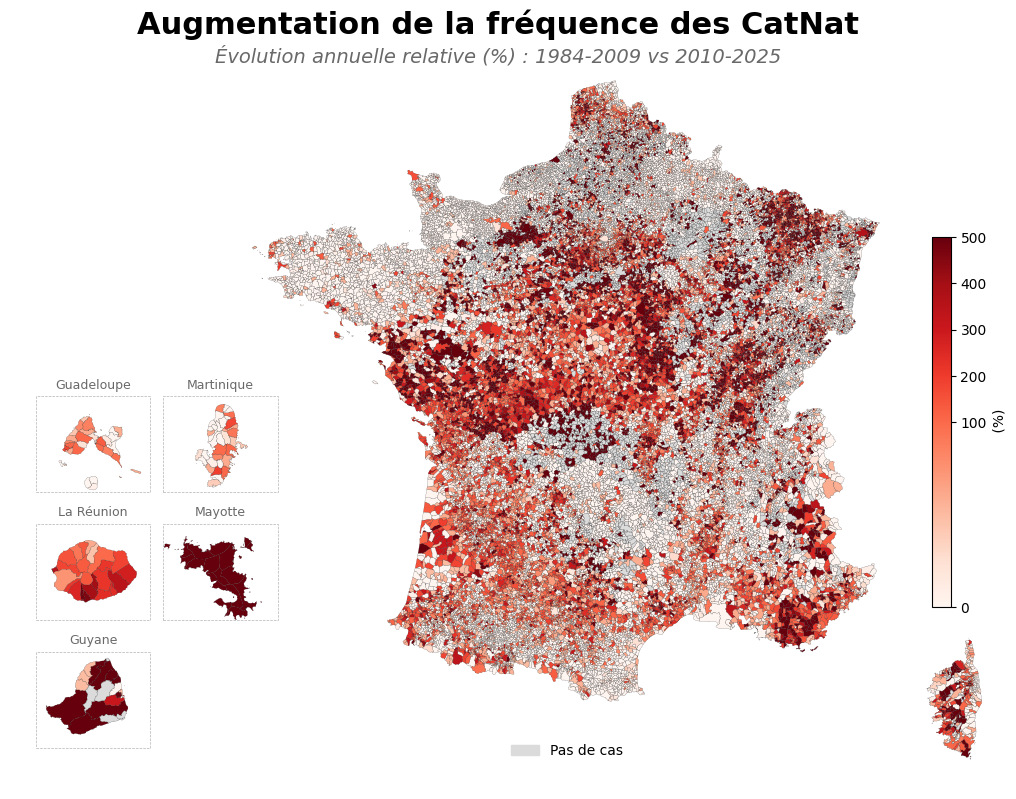

In [21]:
missing_color = "#DBDBDB"

vmin, vcenter, vmax = 0, 100, 500
norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=vcenter, vmax=vmax)

monovariate_map(
    nb_diff_geo,
    col="freq_growth",
    cmap="Reds",
    norm=norm,
    title="Augmentation de la fréquence des CatNat",
    missing_color=missing_color,
    subtitle="Évolution annuelle relative (%) : 1984-2009 vs 2010-2025",
);

## PPRN Couverture RGA


In [22]:
query_pprn = """
SELECT
    code_geo,
    REPLACE(code_modele, 'PPRN-', '') AS pprn,
    STRING_AGG(DISTINCT libelle_risque_2, ' / ') AS pprn_libelle,
    STRING_AGG(DISTINCT libelle_risque_3, ' / ') AS pprn_desc,
    MAX(CAST(approbation AS DATETIME)) AS date_approbation
FROM
    dev.main.pprn_gaspar
WHERE
    libelle_etat = 'Opposable'
GROUP BY
    code_geo, code_modele 
"""

pprn = con.sql(query_pprn)
pprn_df = pprn.df()
pprn_df.head(2)

,code_geo,pprn,pprn_libelle,pprn_desc,date_approbation
0,08485,I,Inondation,Par une crue à débordement lent de cours d'eau,2010-02-08
1,02101,I,Inondation,Par une crue à débordement lent de cours d'eau,2008-06-09


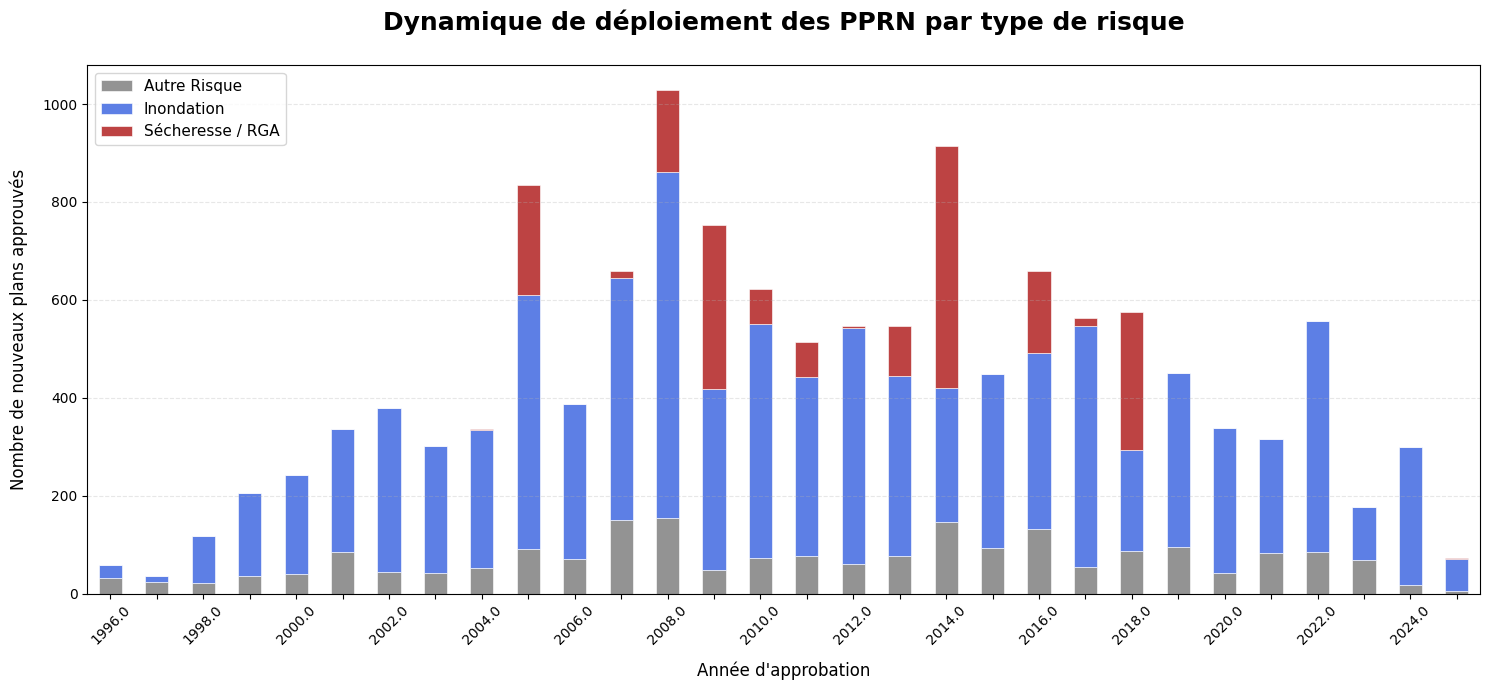

In [25]:
def categorize_pprn(x):
    x_str = str(x).upper()
    if "RGA" == x_str:
        return "Sécheresse / RGA"
    elif "I" == x_str:
        return "Inondation"
    else:
        return "Autre Risque"


pprn_df["type_peril"] = pprn_df["pprn"].apply(categorize_pprn)

# 2. Extraction de l'année et pivotage
pprn_df["approb_year"] = pprn_df["date_approbation"].dt.year
pprn_df = pprn_df[pprn_df["approb_year"] > 1995]
history = pprn_df.groupby(["approb_year", "type_peril"]).size().unstack(fill_value=0)

# 3. Création du graphique
fig, ax = plt.subplots(figsize=(15, 7), facecolor="white")

colors = ["grey", "royalblue", "firebrick"]

history.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    color=colors,
    alpha=0.85,
    edgecolor="white",
    linewidth=0.5,
)

ax.set_title(
    "Dynamique de déploiement des PPRN par type de risque",
    fontsize=18,
    fontweight="bold",
    pad=25,
)
ax.set_xlabel("Année d'approbation", fontsize=12, labelpad=10)
ax.set_ylabel("Nombre de nouveaux plans approuvés", fontsize=12, labelpad=10)
ax.legend(title="", fontsize=11, frameon=True, loc="upper left")
ax.grid(axis="y", linestyle="--", alpha=0.3)

plt.xticks(rotation=45)
n = 2
[l.set_visible(False) for (i, l) in enumerate(ax.xaxis.get_ticklabels()) if i % n != 0]

plt.tight_layout()
plt.show()

In [27]:
pprn_geo = communes_geo.merge(pprn_df, left_on="code", right_on="code_geo", how="left")
pprn_geo["pprn"] = pprn_geo["pprn"].fillna("Pas de Couverture")
pprn_geo, drom_configs = prepare_france_geometry(pprn_geo)

In [28]:
con.execute("INSTALL spatial;")
con.execute("LOAD spatial;")

query = """
        SELECT
            gid,
            niveau,
            surf_m2,
            ST_AsWKB(geom) AS geom,
            code_departement
        FROM rga
        """
rga_geo = con.sql(query).df()
rga_geo["geom"] = gpd.GeoSeries.from_wkb(rga_geo["geom"].map(bytes))
rga_geo = gpd.GeoDataFrame(rga_geo, geometry="geom", crs="EPSG:2154")

In [29]:
rga_geo["niveau_desc"] = rga_geo["niveau"].replace({1: "Faible", 2: "Moyen", 3: "Fort"})
rga_geo_high = rga_geo[rga_geo["niveau"] != 1]
pprn_metropole = pprn_geo[~pprn_geo["code"].astype(str).str.startswith("97")]
pprn_rga = pprn_metropole[pprn_metropole["code_modele"] == "PPRN-RGA"].dissolve()
pprn_metropole_without_rga = pprn_metropole[
    pprn_metropole["code_modele"] != "RGA"
].dissolve()


KeyError: 'code_modele'

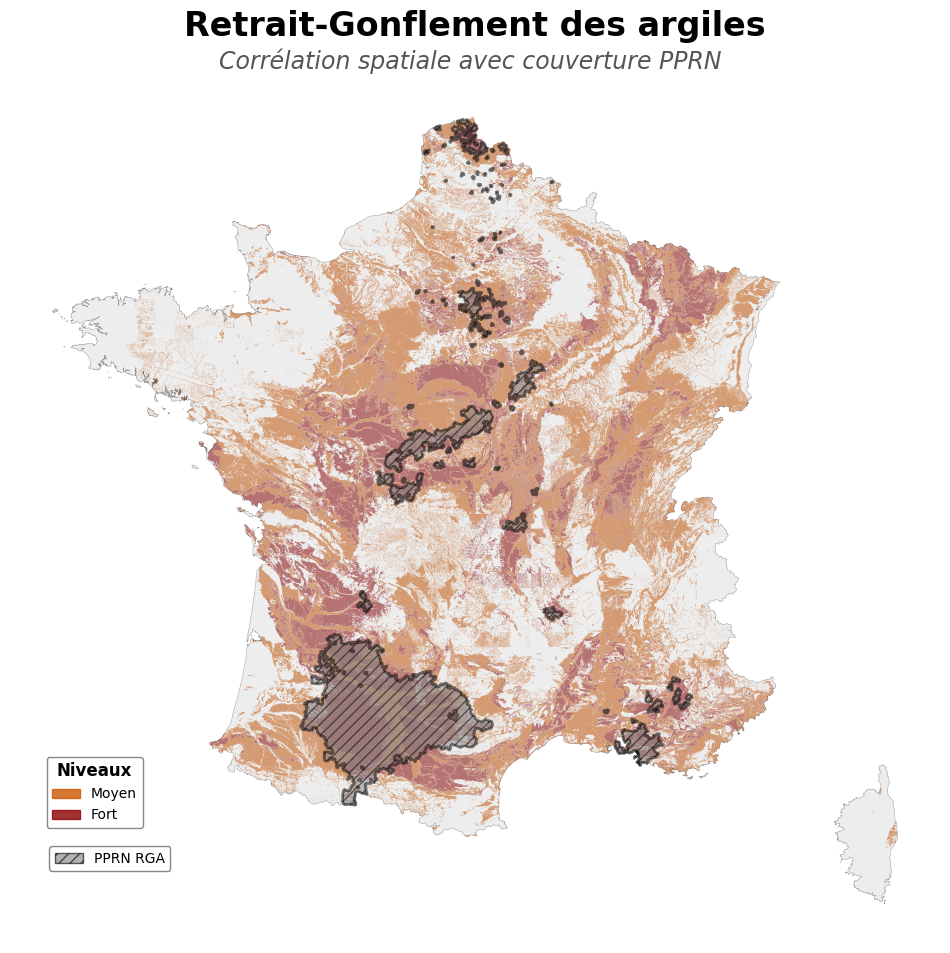

In [ ]:
level_palette = {
    "Moyen": "#CC5500",
    "Fort": "darkred",
}

fig, ax = plt.subplots(figsize=(12, 12))

rga_geo_high.plot(  # .iloc[:2000]
    ax=ax,
    column="niveau_desc",
    alpha=0.8,
    categories=level_palette.keys(),
    color=[level_palette[cat] for cat in rga_geo_high["niveau_desc"]],
)


pprn_metropole_without_rga.plot(
    ax=ax, color="lightgrey", alpha=0.4, linewidth=0.3, edgecolor="black"
)

pprn_rga.plot(
    ax=ax, color="grey", alpha=0.5, hatch="///", linewidth=1.75, edgecolor="black"
)

handles_rga = [
    mpatches.Patch(color=color, alpha=0.8, label=label)
    for label, color in level_palette.items()
]

leg1 = ax.legend(
    handles=handles_rga,
    title="Niveaux",
    loc="lower right",
    bbox_to_anchor=(0.15, 0.125),
    fontsize=10,
    labelcolor="black",
    frameon=True,
    facecolor="white",
    edgecolor="dimgrey",
    title_fontproperties={"weight": "bold", "size": 12},
)
plt.setp(leg1.get_title(), color="black")

ax.add_artist(leg1)

pprn_palette = {
    "PPRN RGA": "grey",
}
handles_pprn = [
    mpatches.Patch(facecolor=c, label=l, alpha=0.6, hatch="///", edgecolor="black")
    for l, c in pprn_palette.items()
]

leg2 = ax.legend(
    handles=handles_pprn,
    title="",
    loc="lower left",
    labelcolor="black",
    bbox_to_anchor=(0.035, 0.075),
    frameon=True,
    facecolor="white",
    edgecolor="dimgrey",
    title_fontproperties={"weight": "bold"},
)
plt.setp(leg2.get_title(), color="black")


ax.set_axis_off()
ax.set_title(
    "Retrait-Gonflement des argiles",
    fontsize=24,
    fontweight="bold",
    color="black",
    pad=30,
)

ax.text(
    0.225,
    1.01,
    "Corrélation spatiale avec couverture PPRN",
    transform=ax.transAxes,
    fontsize=17,
    fontstyle="italic",
    color="#555555",
    ha="left",
)

plt.show()


## DONUT PPRN


In [ ]:
recon_ccr = details_par_catnat[details_par_catnat["libelle_avis"] == "Reconnue"]
recon_ccr["date_debut_evenement"] = pd.to_datetime(recon_ccr["date_debut_evenement"])
recon_ccr = recon_ccr[
    recon_ccr["date_debut_evenement"] > "1995-02"
]  # 1995-02 mise en place PPRN


In [ ]:
pprn_ino = pprn_df[pprn_df["pprn"] == "I"].copy()
pprn_sec = pprn_df[pprn_df["pprn"] == "RGA"].copy()

pprn_ino["date_approbation"] = pd.to_datetime(pprn_ino["date_approbation"])
pprn_sec["date_approbation"] = pd.to_datetime(pprn_sec["date_approbation"])
recon_ccr["date_debut_evenement"] = pd.to_datetime(recon_ccr["date_debut_evenement"])

ccr_pprn = recon_ccr.merge(
    pprn_ino[["code_geo", "date_approbation"]].rename(
        columns={"date_approbation": "app_ino"}
    ),
    on="code_geo",
    how="left",
)
ccr_pprn = ccr_pprn.merge(
    pprn_sec[["code_geo", "date_approbation"]].rename(
        columns={"date_approbation": "app_sec"}
    ),
    on="code_geo",
    how="left",
)

ccr_pprn["is_protected"] = np.where(
    (ccr_pprn["app_ino"] < ccr_pprn["date_debut_evenement"])
    & (ccr_pprn["nom_peril"].str.contains("Inondations", na=False)),
    1,
    0,
)

ccr_pprn["is_sec_protected"] = np.where(
    (ccr_pprn["app_sec"] < ccr_pprn["date_debut_evenement"])
    & (ccr_pprn["nom_peril"].str.contains("Sécheresse", na=False)),
    1,
    0,
)

data_ino = (
    ccr_pprn[ccr_pprn["nom_peril"].str.contains("Inondations", na=False)][
        "is_protected"
    ]
    .value_counts()
    .sort_index()
)
data_sec = (
    ccr_pprn[ccr_pprn["nom_peril"].str.contains("Sécheresse", na=False)][
        "is_sec_protected"
    ]
    .value_counts()
    .sort_index()
)

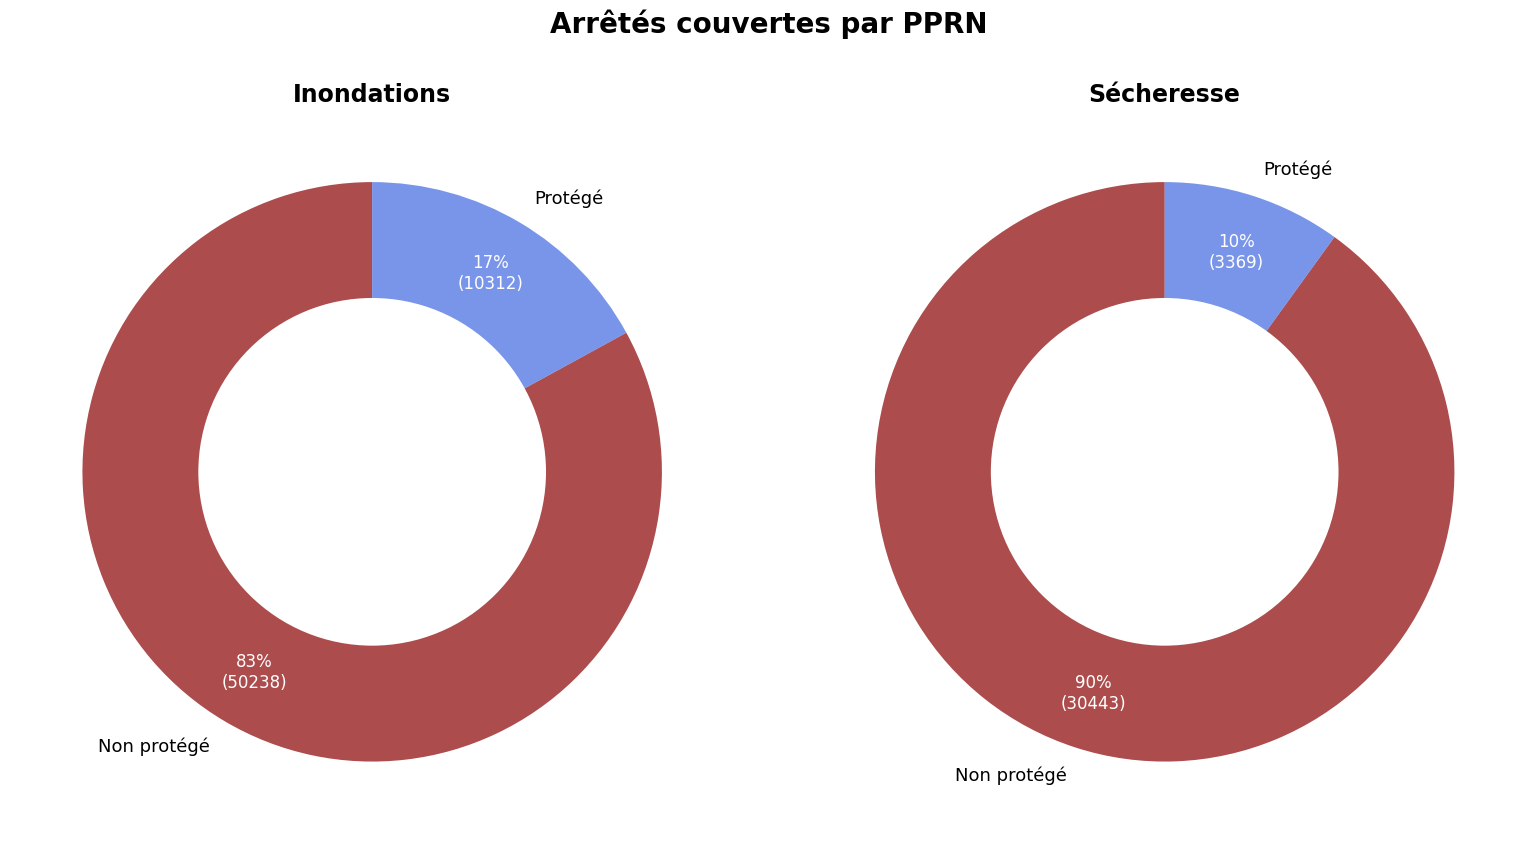

In [43]:
labels = ["Non protégé", "Protégé"]
colors = ["darkred", "royalblue"]


def func(pct, allvals):
    absolute = int(round(pct / 100.0 * sum(allvals)))
    return f"{pct:.0f}%\n({absolute:d})"


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8), facecolor="white")

wedges1, texts1, autotexts1 = ax1.pie(
    data_ino,
    labels=labels,
    autopct=lambda pct: func(pct, data_ino),
    startangle=90,
    colors=colors,
    pctdistance=0.8,
    textprops={
        "fontsize": 12,
    },
    wedgeprops={"alpha": 0.7},
)
ax1.add_artist(plt.Circle((0, 0), 0.6, fc="white"))
ax1.set_title("Inondations", fontsize=17, fontweight="bold")

wedges2, texts2, autotexts2 = ax2.pie(
    data_sec,
    labels=labels,
    autopct=lambda pct: func(pct, data_sec),
    startangle=90,
    colors=colors,
    pctdistance=0.8,
    textprops={"fontsize": 12},
    wedgeprops={"alpha": 0.7},
)
ax2.add_artist(plt.Circle((0, 0), 0.6, fc="white"))
ax2.set_title("Sécheresse", fontsize=17, fontweight="bold")

for at in autotexts1 + autotexts2:
    at.set_color("white")
    at.set_fontsize(12)

for t in texts1 + texts2:
    t.set_fontsize(13)

plt.suptitle(
    "Arrêtés couvertes par PPRN",
    fontsize=20,
    fontweight="bold",
    y=1.05,
)

plt.tight_layout()
plt.show()

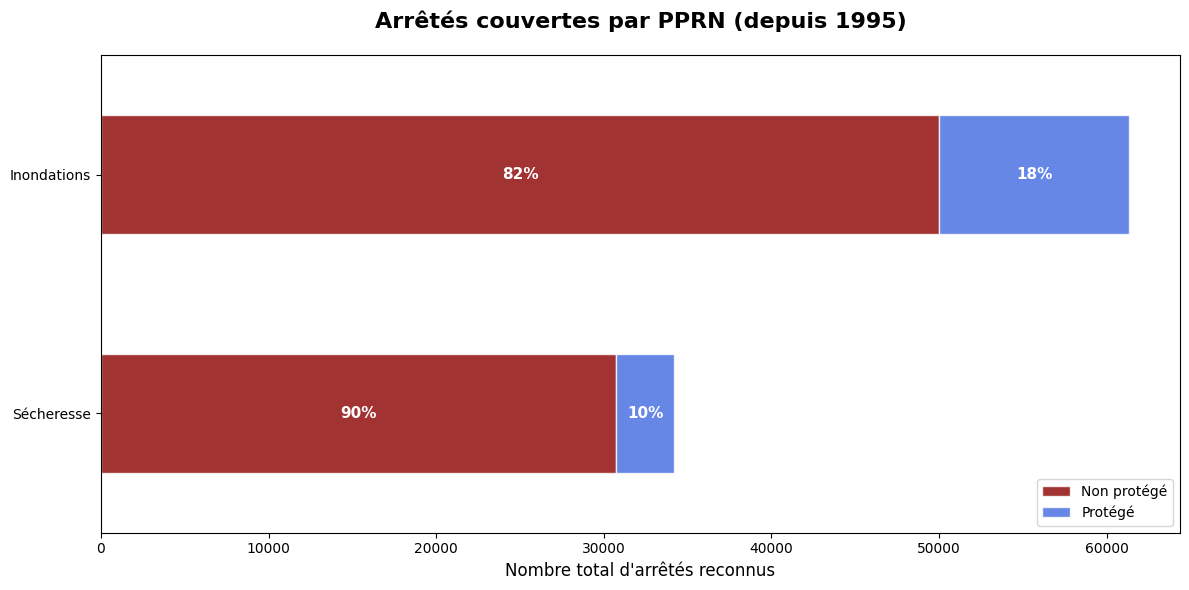

In [ ]:
plot_df = pd.DataFrame(
    {
        "Non protégé": [data_ino.get(0, 0), data_sec.get(0, 0)],
        "Protégé": [data_ino.get(1, 1), data_sec.get(1, 0)],
    },
    index=["Inondations", "Sécheresse"],
)

fig, ax = plt.subplots(figsize=(12, 6), facecolor="white")
colors = ["darkred", "royalblue"]

plot_df = plot_df.sort_values(by="Non protégé", ascending=True)

plot_df.plot(
    kind="barh", stacked=True, ax=ax, color=colors, alpha=0.8, edgecolor="white"
)

for i in range(len(plot_df)):
    total = plot_df.iloc[i].sum()
    current_left = 0
    for j, col in enumerate(plot_df.columns):
        val = plot_df.iloc[i, j]
        if val > 0:
            percentage = (val / total) * 100
            text_x = current_left + (val / 2)
            label = f"{percentage:.0f}%"

            ax.text(
                text_x,
                i,
                label,
                ha="center",
                va="center",
                color="white",
                fontweight="bold",
                fontsize=11,
            )
        current_left += val

# 4. Stylisation
ax.set_title(
    "Arrêtés couvertes par PPRN (depuis 1995)", fontsize=16, fontweight="bold", pad=20
)
ax.set_xlabel("Nombre total d'arrêtés reconnus", fontsize=12)
ax.set_ylabel("", fontsize=12)
ax.legend(title="", frameon=True, loc="lower right")
ax.grid(False)

plt.tight_layout()
plt.show()

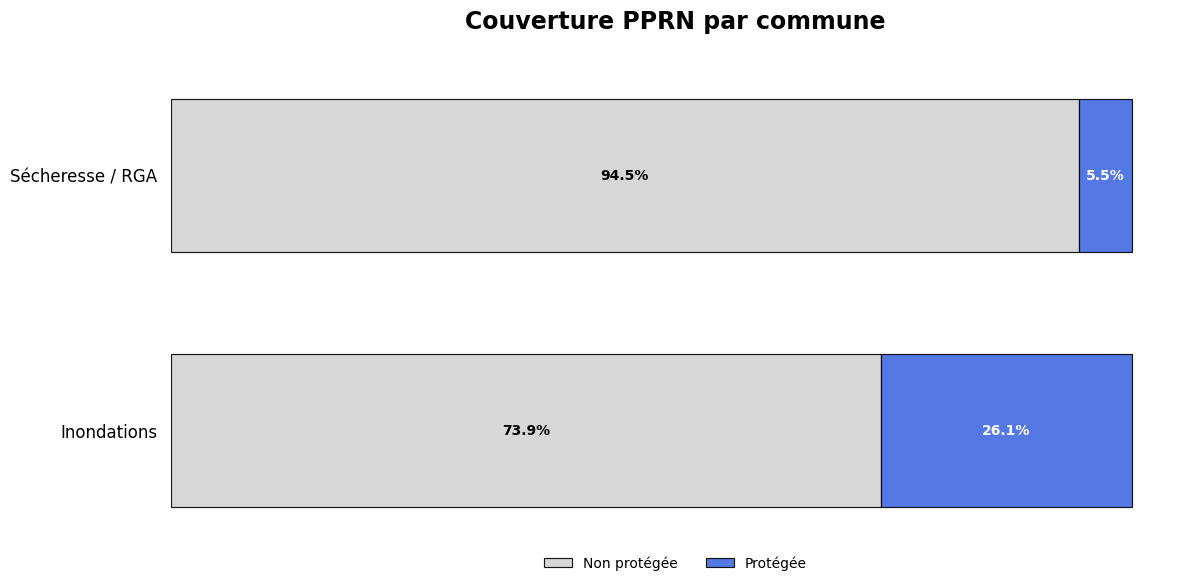

In [45]:
total_communes = communes_geo["code"].nunique()

n_pprn_ino = pprn_ino["code_geo"].nunique()
n_pprn_sec = pprn_sec["code_geo"].nunique()

muni_plot_df = pd.DataFrame(
    {
        "Non protégée": [total_communes - n_pprn_ino, total_communes - n_pprn_sec],
        "Protégée": [n_pprn_ino, n_pprn_sec],
    },
    index=["Inondations", "Sécheresse / RGA"],
)

fig, ax = plt.subplots(figsize=(12, 6), facecolor="white")
colors = ["lightgrey", "royalblue"]

muni_plot_df.plot(
    kind="barh",
    stacked=True,
    ax=ax,
    color=colors,
    alpha=0.9,
    width=0.6,
    edgecolor="black",
    linewidth=0.85,
)

for i in range(len(muni_plot_df)):
    total = muni_plot_df.iloc[i].sum()
    current_left = 0
    for j, col in enumerate(muni_plot_df.columns):
        val = muni_plot_df.iloc[i, j]
        if val > 0:
            pct = (val / total) * 100
            text_x = current_left + (val / 2)

            txt_color = "black" if col == "Non protégée" else "white"

            ax.text(
                text_x,
                i,
                f"{pct:.1f}%",
                ha="center",
                va="center",
                color=txt_color,
                fontweight="bold",
                fontsize=10,
            )
        current_left += val

ax.set_title("Couverture PPRN par commune", fontsize=17, fontweight="bold", pad=5)
ax.set_xlabel("Nombre total de communes", fontsize=12)
ax.set_ylabel("", fontsize=12)

ax.xaxis.set_visible(False)
ax.spines["top"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_visible(False)
ax.tick_params(axis="y", which="both", length=0, labelsize=12, pad=10)
ax.legend(
    title=None, frameon=False, loc="upper center", bbox_to_anchor=(0.5, 0.05), ncol=2
)
ax.grid(False)

plt.tight_layout()
plt.show()

## LOCAL & SPATIAL ANALYSIS


In [54]:
def clean_comptes(comptes):
    types_to_keep = [
        "dettes",
        "prime d'assurance",
        "depenses",
        "produits",
    ]
    comptes_filtered = comptes[comptes["type_compte"].isin(types_to_keep)].copy()

    comptes_final = comptes_filtered.pivot_table(
        index=[
            "code_geo_from_siren",
            "nom_com",
            "annee",
        ],
        columns="type_compte",
        values="solde",
        aggfunc="sum",
    ).reset_index()

    comptes_final = comptes_final.rename(
        columns={
            "dettes": "dettes",
            "prime d'assurance": "primes",
            "depenses": "depenses",
            "produits": "produits",
        }
    )

    comptes_final["solde_annuel"] = (
        comptes_final["produits"] - comptes_final["depenses"]
    )
    comptes_final["ratio_dettes_produits"] = (
        comptes_final["dettes"] / comptes_final["produits"]
    ) * 100
    comptes_final["ratio_dettes_depenses"] = (
        comptes_final["dettes"].abs() / comptes_final["depenses"]
    ) * 100
    comptes_final["ratio_primes_depenses"] = (
        comptes_final["primes"] / comptes_final["depenses"]
    ) * 100

    cols_to_fix = ["primes", "dettes", "depenses", "produits"]

    for col in cols_to_fix:
        if col in comptes_final.columns:
            comptes_final[col] = comptes_final[col].abs()

    return comptes_final


def spatial_lag_analysis(gdf, col, risk_cmap, w):

    gdf[col + "_slag"] = libpysal.weights.lag_spatial(w, gdf[col].fillna(0))
    moran_loc = Moran_Local(gdf[col].fillna(0), w)

    # Maps
    fig, ax = plt.subplots(1, 2, figsize=(16, 8))

    gdf.plot(
        column=col,
        cmap=risk_cmap,  # coolwarm
        legend=True,
        scheme="quantiles",
        k=8,
        edgecolor="lightgrey",
        linewidth=0.1,
        ax=ax[0],
    )
    ax[0].set_title("Original: % Change vs Median Primes", fontsize=14)
    ax[0].axis("off")

    gdf.plot(
        column=col + "_slag",
        cmap=risk_cmap,
        legend=True,
        scheme="quantiles",
        k=8,
        edgecolor="lightgrey",
        linewidth=0.1,
        ax=ax[1],
    )
    ax[1].set_title("Spatial Lag: Regional Environment", fontsize=14)
    ax[1].axis("off")

    plt.tight_layout()
    plt.show()

    # Moran Local
    fig, ax = plt.subplots(figsize=(10, 10))

    moran_scatterplot(moran_loc, p=0.05, ax=ax)

    ax.set_xlabel("Evo Prime (% Change)", fontsize=12)
    ax.set_ylabel("Spatial Lag (Neighbor Avg)", fontsize=12)
    ax.set_title(
        "Moran Scatterplot: Local vs Regional Evolution", fontsize=15, fontweight="bold"
    )

    ax.grid(color="grey", linestyle="--", linewidth=0.5, alpha=0.5)

    plt.show()

    # LISA Clusters
    lisa_cluster(moran_loc, gdf, p=0.05, figsize=(9, 9))
    plt.show()

    quadrant_labels = {
        1: "Hotspot (HH)",
        2: "Outlier (LH)",
        3: "Coldspot (LL)",
        4: "Outlier (HL)",
    }

    significant = moran_loc.p_sim < 0.05

    cluster_df = pd.DataFrame(
        {
            "code_geo": gdf["code"],
            "evo_prime": moran_loc.y,
            "quadrant": moran_loc.q,
            "p_value": moran_loc.p_sim,
        }
    )

    cluster_df["cluster_type"] = cluster_df["quadrant"].map(quadrant_labels)
    cluster_df.loc[~significant, "cluster_type"] = "Insignificant"
    return cluster_df


def plot_all_lisa_trends(
    cluster_df, timeseries_df, target_var="primes", geo_col="code_geo"
):
    lisa_classes = ["Hotspot (HH)", "Coldspot (LL)", "Outlier (HL)", "Outlier (LH)"]

    national_median = timeseries_df.groupby("annee")[target_var].median().reset_index()

    fig, axes = plt.subplots(2, 2, figsize=(20, 12), sharex=True)
    axes = axes.flatten()

    for i, cluster in enumerate(lisa_classes):
        selection = cluster_df[cluster_df["cluster_type"] == cluster]

        if len(selection) == 0:
            axes[i].text(0.5, 0.5, f"No data for {cluster}", ha="center")
            continue

        data_plot = timeseries_df[
            timeseries_df["code_geo_from_siren"].isin(selection[geo_col])
        ]

        sns.lineplot(
            data=data_plot,
            x="annee",
            y=target_var,
            ax=axes[i],
            marker="o",
            linewidth=4,
            label="Cluster Median",
            color="darkred" if "Hotspot" in cluster else "steelblue",
            estimator="median",
            errorbar=("ci", 95),
        )

        sns.lineplot(
            data=national_median,
            x="annee",
            y=target_var,
            ax=axes[i],
            color="grey",
            linestyle="--",
            linewidth=2,
            label="National Median",
            alpha=0.7,
        )

        axes[i].set_title(
            f"Trend for {cluster} (n={len(selection)})", fontsize=16, fontweight="bold"
        )
        axes[i].set_ylabel(f"Median {target_var}")
        axes[i].legend(loc="upper left")
        axes[i].grid(True, alpha=0.2)

    plt.tight_layout()
    plt.suptitle(
        f"Temporal Evolution: {target_var} vs. National Benchmark", fontsize=22, y=1.03
    )
    plt.show()


def bivariate_spatial_analysis(gdf, col_x, col_y, risk_cmap):

    df_clean = (
        gdf.replace([np.inf, -np.inf], np.nan).dropna(subset=[col_x, col_y]).copy()
    )

    w = libpysal.weights.Queen.from_dataframe(df_clean)
    w.transform = "R"

    df_clean[col_y + "_slag"] = libpysal.weights.lag_spatial(w, df_clean[col_y])

    moran_bv_loc = Moran_Local_BV(df_clean[col_x], df_clean[col_y], w)

    fig, ax = plt.subplots(1, 2, figsize=(16, 8))

    df_clean.plot(
        column=col_x,
        cmap=risk_cmap,
        legend=True,
        scheme="quantiles",
        k=8,
        edgecolor="lightgrey",
        linewidth=0.1,
        ax=ax[0],
    )
    ax[0].set_title(f"Local Variable (X): {col_x}", fontsize=14)
    ax[0].axis("off")

    df_clean.plot(
        column=col_y + "_slag",
        cmap=risk_cmap,
        legend=True,
        scheme="quantiles",
        k=8,
        edgecolor="lightgrey",
        linewidth=0.1,
        ax=ax[1],
    )
    ax[1].set_title(f"Regional Variable (Lag Y): {col_y}", fontsize=14)
    ax[1].axis("off")

    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(10, 10))

    moran_scatterplot(moran_bv_loc, p=0.05, ax=ax)

    ax.set_xlabel(f"Local {col_x}", fontsize=12)
    ax.set_ylabel(f"Spatial Lag of {col_y}", fontsize=12)
    ax.set_title(
        f"Bivariate Scatterplot: {col_x} vs Regional {col_y}",
        fontsize=15,
        fontweight="bold",
    )

    ax.grid(color="grey", linestyle="--", linewidth=0.5, alpha=0.5)
    plt.show()

    lisa_cluster(moran_bv_loc, df_clean, p=0.05, figsize=(9, 9))
    plt.title(f"Bivariate Clusters: {col_x} vs {col_y}", fontsize=15, fontweight="bold")
    plt.show()

    quadrant_labels = {
        1: "Hotspot (HH)",
        2: "Outlier (LH)",  # Low X, High Lag Y
        3: "Coldspot (LL)",
        4: "Outlier (HL)",  # High X, Low Lag Y
    }

    significant = moran_bv_loc.p_sim < 0.05

    cluster_df = pd.DataFrame(
        {
            "code_geo": df_clean["code"],
            f"local_{col_x}": df_clean[col_x],
            f"regional_lag_{col_y}": df_clean[col_y + "_slag"],
            "quadrant": moran_bv_loc.q,
            "p_value": moran_bv_loc.p_sim,
        }
    )

    cluster_df["cluster_type"] = cluster_df["quadrant"].map(quadrant_labels)
    cluster_df.loc[~significant, "cluster_type"] = "Insignificant"

    return cluster_df

In [55]:
query_budget = """
                SELECT
                    *
                FROM budget_per_compte_communes
                """

comptes = con.sql(query_budget)
comptes_df = comptes.df()
comptes_df.head(2)

,code_departement,code_insee,siret,siren,annee,code_region,type_compte,code_geo_from_siren,nom_com,code_geo,solde_debiteur,solde_crediteur,solde
0,38,emp,21380504700064,213805047,2012,84,dettes,38504,Theys,38emp,0.0,965607.17,-965607.17
1,39,011,21390011100013,213900111,2012,27,dettes,39011,Annoire,39011,0.0,170019.14,-170019.14


In [56]:
comptes_df_clean = clean_comptes(comptes_df)
details_par_catnat["annee"] = details_par_catnat["date_debut_evenement"].dt.year
details_par_catnat["is_refusal"] = details_par_catnat["libelle_avis"].str.contains(
    "Non reconnue", case=False, na=False
)
refusal_stats = (
    details_par_catnat.groupby(["code_geo", "annee"])["is_refusal"]
    .agg(total_dossiers="count", nb_refus="sum", taux_refus="mean")
    .reset_index()
)

refusal_stats["taux_refus"] = refusal_stats["taux_refus"] * 100

In [57]:
# CCR
risk_colors = ["#228B22", "#FFD700", "#8B0000"]
risk_cmap = LinearSegmentedColormap.from_list("CatNatRisk", risk_colors)

comptes = comptes_df_clean.copy()
comptes["annee"] = comptes["annee"].astype(str)
df_pivot = comptes.pivot(index="code_geo_from_siren", columns="annee", values="primes")
df_pivot["evo_primes_20_24"] = df_pivot["2024"] / df_pivot["2020"]
df_pivot["rel_evo_primes_20_24"] = (
    (df_pivot["2024"] - df_pivot["2020"]) / df_pivot["2020"].replace(0, np.nan)
) * 100
df_pivot["mediane_historique"] = df_pivot.median(axis=1)
df_pivot["ecart_vs_primes_mediane"] = (
    (df_pivot["2024"] - df_pivot["mediane_historique"])
    / df_pivot["mediane_historique"]
    * 100
)
df_pivot = df_pivot[
    ["evo_primes_20_24", "rel_evo_primes_20_24", "ecart_vs_primes_mediane"]
]

period_stats = per_period(details_par_catnat, bins=[1984, 2010, 2026])
period_stats["diff_catnat"] = period_stats["post"] - period_stats["pre"]
period_stats = period_stats[["diff_catnat", "freq_growth"]]

var_df = df_pivot.merge(period_stats, left_index=True, right_index=True)
var_geo = communes_geo.merge(
    var_df, left_on="code", right_index=True, how="left"
).fillna(0)

var_geo, _ = prepare_france_geometry(var_geo)

"""
w = libpysal.weights.Queen.from_dataframe(var_geo)
w.transform = "R"
"""

'\nw = libpysal.weights.Queen.from_dataframe(var_geo)\nw.transform = "R"\n'

('WARNING: ', 156, ' is an island (no neighbors)')
('WARNING: ', 158, ' is an island (no neighbors)')
('WARNING: ', 159, ' is an island (no neighbors)')
('WARNING: ', 1573, ' is an island (no neighbors)')
('WARNING: ', 2845, ' is an island (no neighbors)')
('WARNING: ', 6236, ' is an island (no neighbors)')
('WARNING: ', 6489, ' is an island (no neighbors)')
('WARNING: ', 14927, ' is an island (no neighbors)')
('WARNING: ', 19359, ' is an island (no neighbors)')
('WARNING: ', 20726, ' is an island (no neighbors)')
('WARNING: ', 20727, ' is an island (no neighbors)')
('WARNING: ', 34090, ' is an island (no neighbors)')
('WARNING: ', 35237, ' is an island (no neighbors)')
('WARNING: ', 35255, ' is an island (no neighbors)')
('WARNING: ', 35256, ' is an island (no neighbors)')


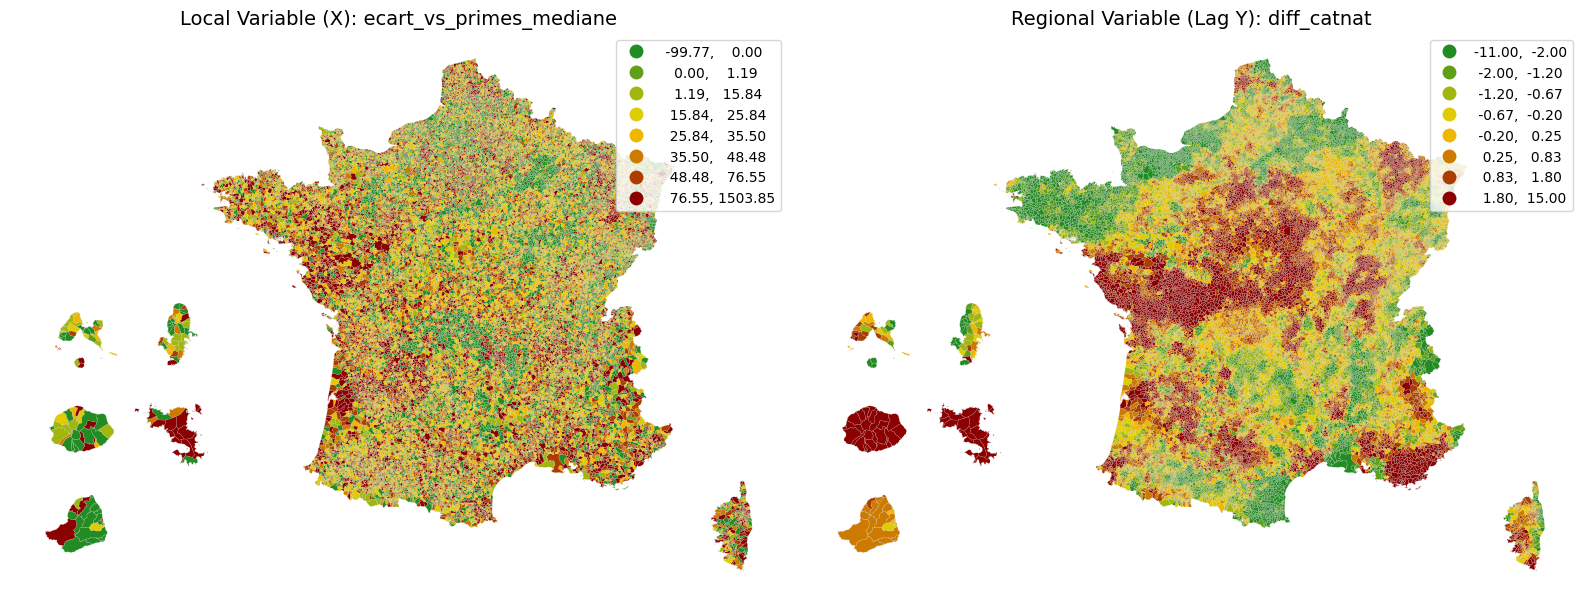

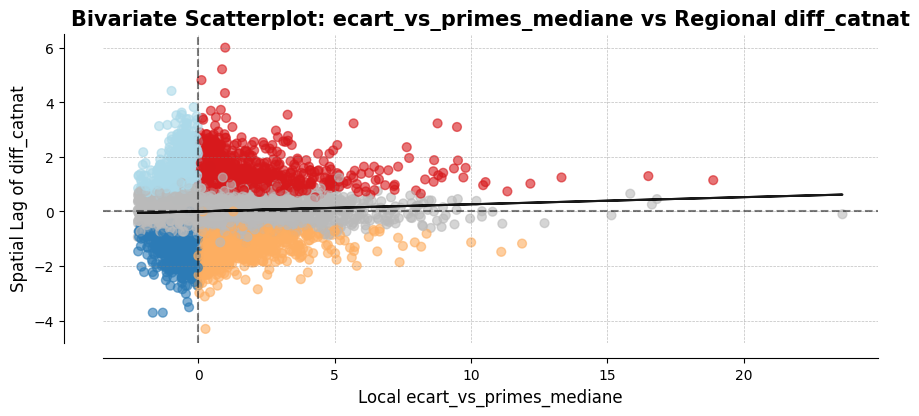

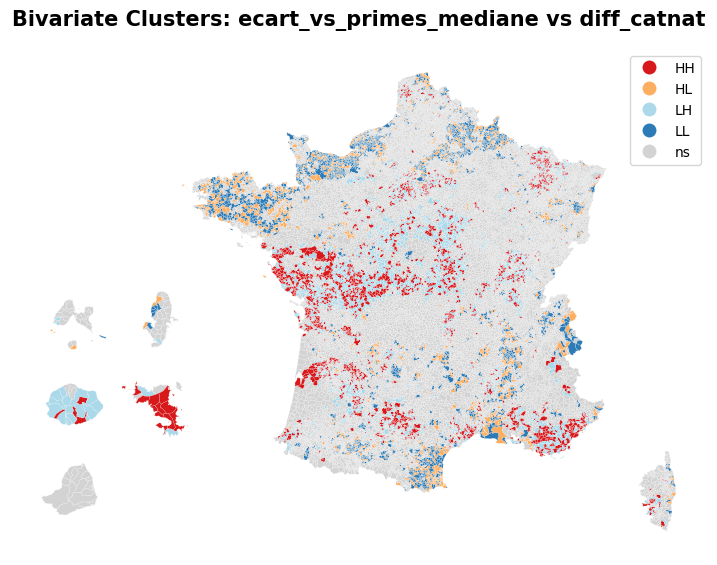

In [58]:
cluster_bi_1 = bivariate_spatial_analysis(
    var_geo, col_x="ecart_vs_primes_mediane", col_y="diff_catnat", risk_cmap=risk_cmap
)

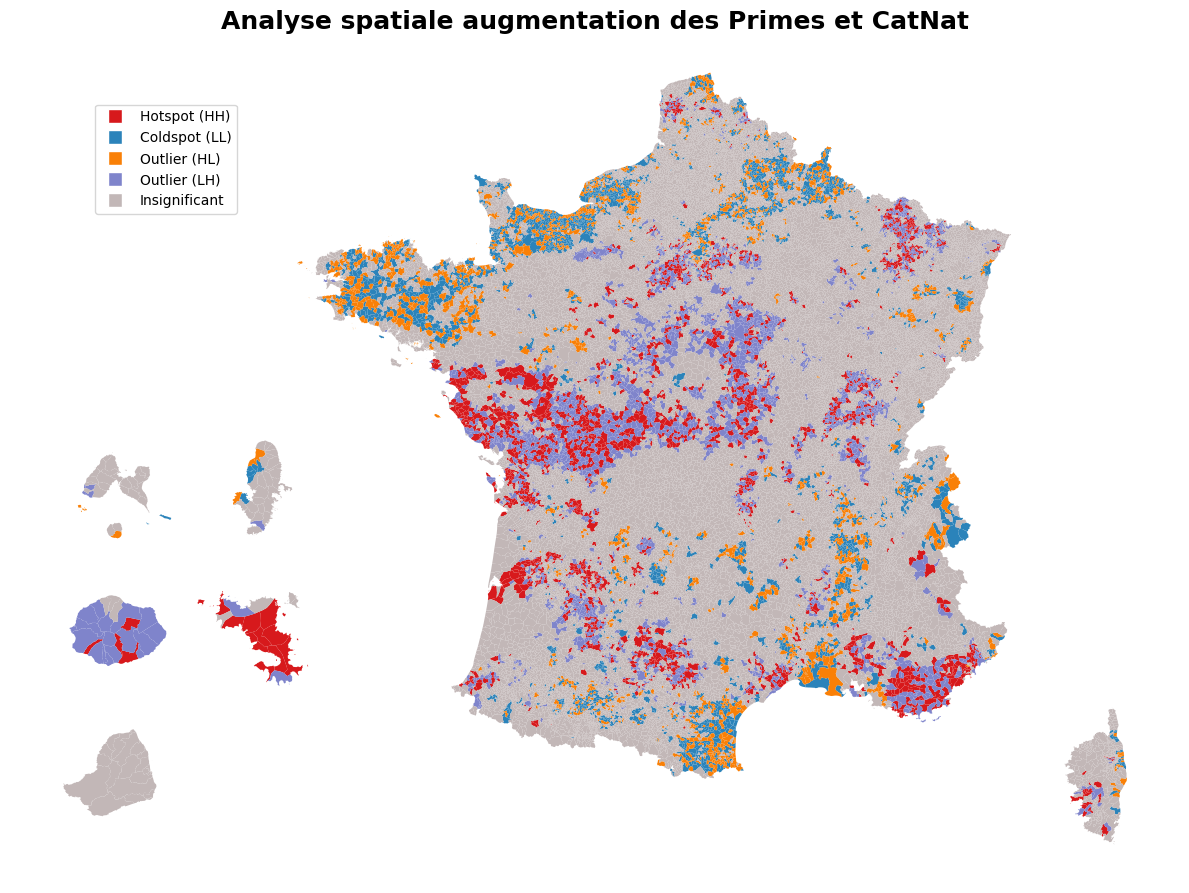

In [ ]:
com_geo, _ = prepare_france_geometry(communes_geo)

map_df = com_geo.merge(cluster_bi_1, left_on="code", right_on="code_geo", how="left")

color_map = {
    "Hotspot (HH)": "#d7191c",
    "Coldspot (LL)": "#2b83ba",
    "Outlier (HL)": "#f98007",
    "Outlier (LH)": "#7f84cb",
    "Insignificant": "#c2b7b7",
}

fig, ax = plt.subplots(1, 1, figsize=(12, 12))

# com_geo.plot(ax=ax, color="white", edgecolor="0.8", linewidth=0.1)

for cluster, color in color_map.items():
    subset = map_df[map_df["cluster_type"] == cluster]
    if not subset.empty:
        subset.plot(ax=ax, color=color, label=cluster, edgecolor="none")

ax.set_title(
    "Analyse spatiale augmentation des Primes et CatNat",
    fontsize=18,
    fontweight="bold",
    pad=-5,
)
ax.set_axis_off()

legend_elements = [
    Line2D([0], [0], marker="s", color="w", label=k, markerfacecolor=v, markersize=10)
    for k, v in color_map.items()
]
ax.legend(handles=legend_elements, bbox_to_anchor=(0.2, 0.925), title="")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

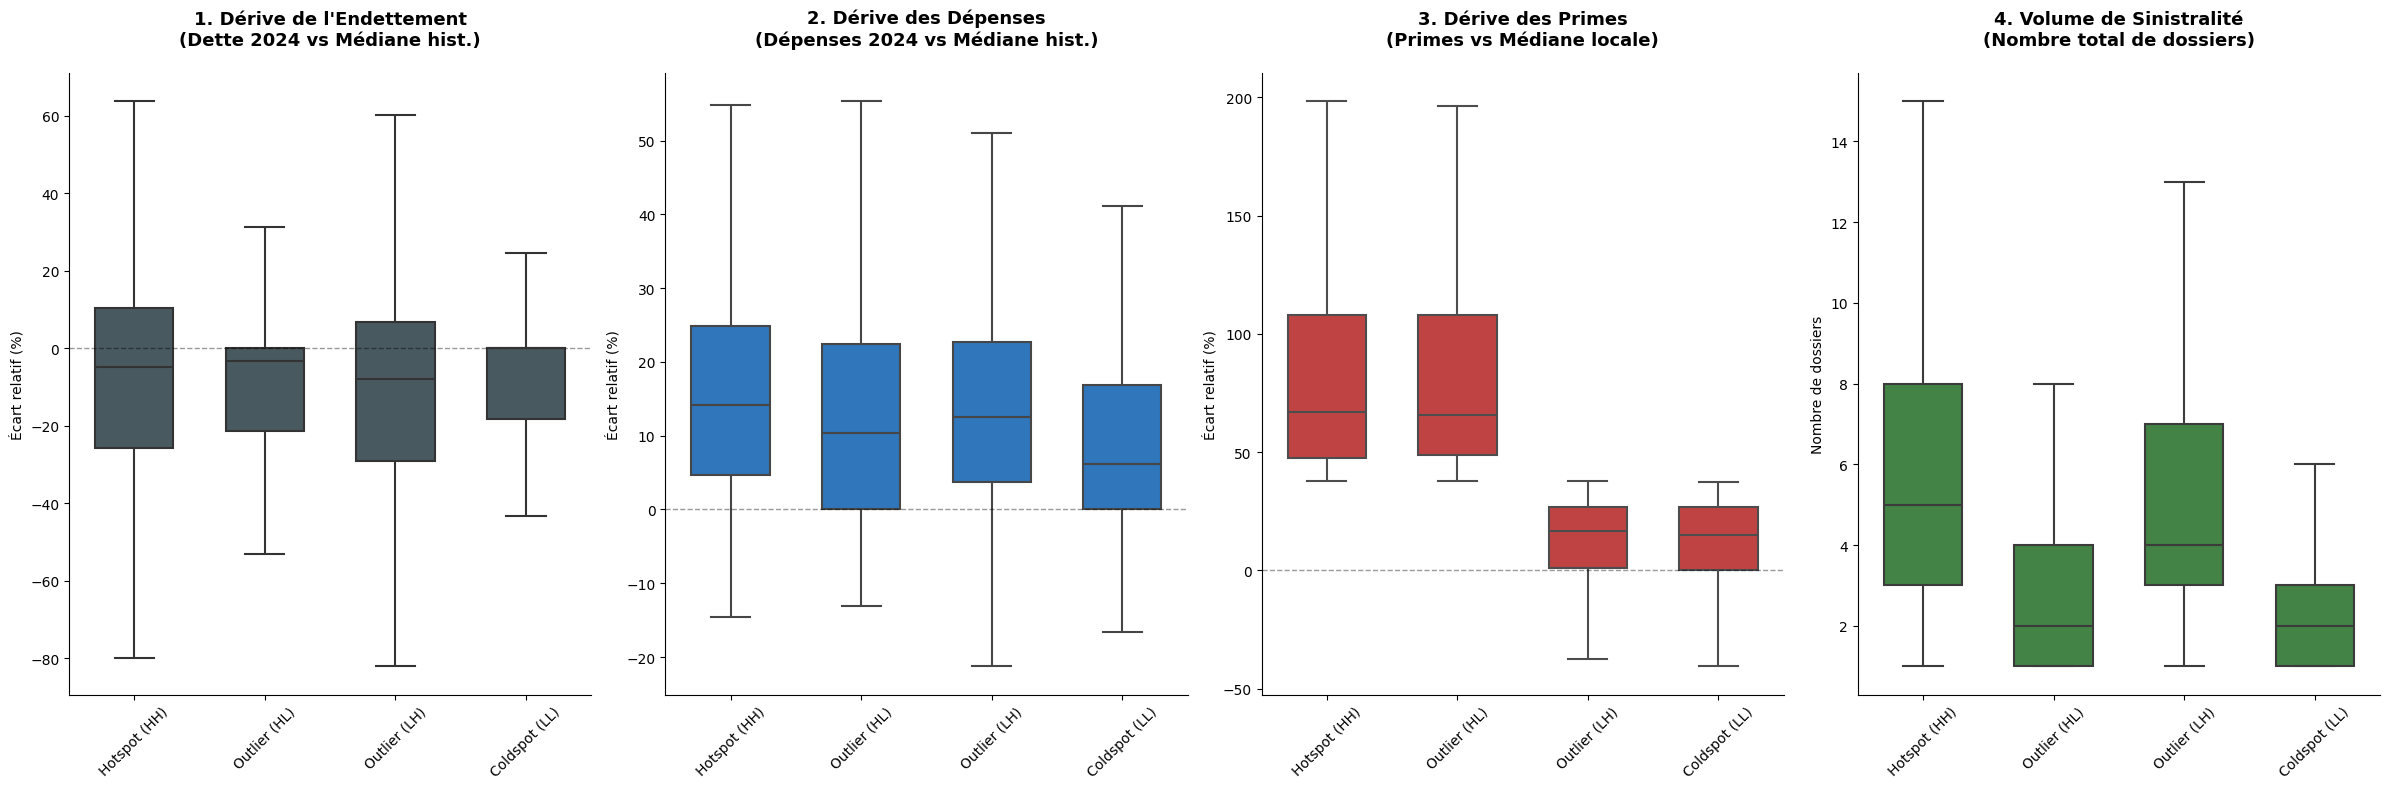

,ecart_vs_dettes_mediane,ecart_vs_depenses_mediane,ecart_vs_primes_mediane,total_dossiers_cumules
cluster_type,,,,
Hotspot (HH),68.43 %,16.53 %,99.53 %,6.1
Outlier (HL),117.61 %,13.02 %,93.60 %,2.9
Outlier (LH),70.81 %,16.15 %,11.98 %,5.3
Coldspot (LL),2.57 %,10.32 %,10.13 %,2.6


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

comptes_final_plot = comptes_df_clean.merge(
    refusal_stats,
    left_on=["annee", "code_geo_from_siren"],
    right_on=["annee", "code_geo"],
)

df_pivot = comptes_final_plot.pivot_table(
    index="code_geo",
    columns="annee",
    values=["dettes", "depenses", "total_dossiers"],
    aggfunc="sum",
)

df_pivot.columns = [f"{val}_{int(ann)}" for val, ann in df_pivot.columns]

cols_dette = [c for c in df_pivot.columns if "dette" in c]
mediane_dette = df_pivot[cols_dette].median(axis=1)
df_pivot["ecart_vs_dettes_mediane"] = (
    (df_pivot["dettes_2024"] - mediane_dette) / mediane_dette * 100
).replace([np.inf, -np.inf], np.nan)

cols_depenses = [c for c in df_pivot.columns if "depenses" in c]
mediane_depenses = df_pivot[cols_depenses].median(axis=1)
df_pivot["ecart_vs_depenses_mediane"] = (
    (df_pivot["depenses_2024"] - mediane_depenses) / mediane_depenses * 100
).replace([np.inf, -np.inf], np.nan)

cols_dossiers = [c for c in df_pivot.columns if "total_dossiers" in c]
df_pivot["total_dossiers_cumules"] = df_pivot[cols_dossiers].sum(axis=1)

df_pivot = df_pivot.reset_index()


lisa_stats_df = cluster_bi_1.merge(
    df_pivot[
        [
            "code_geo",
            "ecart_vs_dettes_mediane",
            "ecart_vs_depenses_mediane",
            "total_dossiers_cumules",
        ]
    ],
    on="code_geo",
    how="inner",
)

lisa_stats_df = lisa_stats_df.rename(
    columns={"local_ecart_vs_primes_mediane": "ecart_vs_primes_mediane"}
)

lisa_stats_clean = lisa_stats_df[
    lisa_stats_df["cluster_type"] != "Insignificant"
].copy()

cluster_order = (
    lisa_stats_clean.groupby("cluster_type")["ecart_vs_primes_mediane"]
    .median()
    .sort_values(ascending=False)
    .index
)


fig, axes = plt.subplots(1, 4, figsize=(24, 8), facecolor="white")
colors = ["#455A64", "#1976D2", "#D32F2F", "#388E3C"]  # Gris, Bleu, Rouge, Vert

metrics = [
    "ecart_vs_dettes_mediane",
    "ecart_vs_depenses_mediane",
    "ecart_vs_primes_mediane",
    "total_dossiers_cumules",
]

titles = [
    "1. Dérive de l'Endettement\n(Dette 2024 vs Médiane hist.)",
    "2. Dérive des Dépenses\n(Dépenses 2024 vs Médiane hist.)",
    "3. Dérive des Primes\n(Primes vs Médiane locale)",
    "4. Volume de Sinistralité\n(Nombre total de dossiers)",
]

for i, col in enumerate(metrics):
    sns.boxplot(
        data=lisa_stats_clean,
        x="cluster_type",
        y=col,
        ax=axes[i],
        color=colors[i],
        order=cluster_order,
        showfliers=False,
        width=0.6,
        linewidth=1.5,
    )

    axes[i].set_title(titles[i], fontsize=13, fontweight="bold", pad=20)
    axes[i].set_ylabel("Écart relatif (%)" if i < 3 else "Nombre de dossiers")
    axes[i].set_xlabel("")
    axes[i].tick_params(axis="x", rotation=45)

    if i < 3:
        axes[i].axhline(0, color="black", linestyle="--", alpha=0.4, linewidth=1)

    axes[i].spines["top"].set_visible(False)
    axes[i].spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


lisa_group_summary = lisa_stats_clean.groupby("cluster_type").mean(numeric_only=True)
lisa_group_summary = lisa_group_summary.reindex(cluster_order)

cols_table = [
    "ecart_vs_dettes_mediane",
    "ecart_vs_depenses_mediane",
    "ecart_vs_primes_mediane",
    "total_dossiers_cumules",
]

format_dict = {
    "ecart_vs_dettes_mediane": "{:.2f} %",
    "ecart_vs_depenses_mediane": "{:.2f} %",
    "ecart_vs_primes_mediane": "{:.2f} %",
    "total_dossiers_cumules": "{:.1f}",
}

display(
    lisa_group_summary[cols_table]
    .style.format(format_dict)
    .background_gradient(cmap="YlOrRd", axis=0)
    .set_caption("Moyennes par Type de Cluster LISA")
)

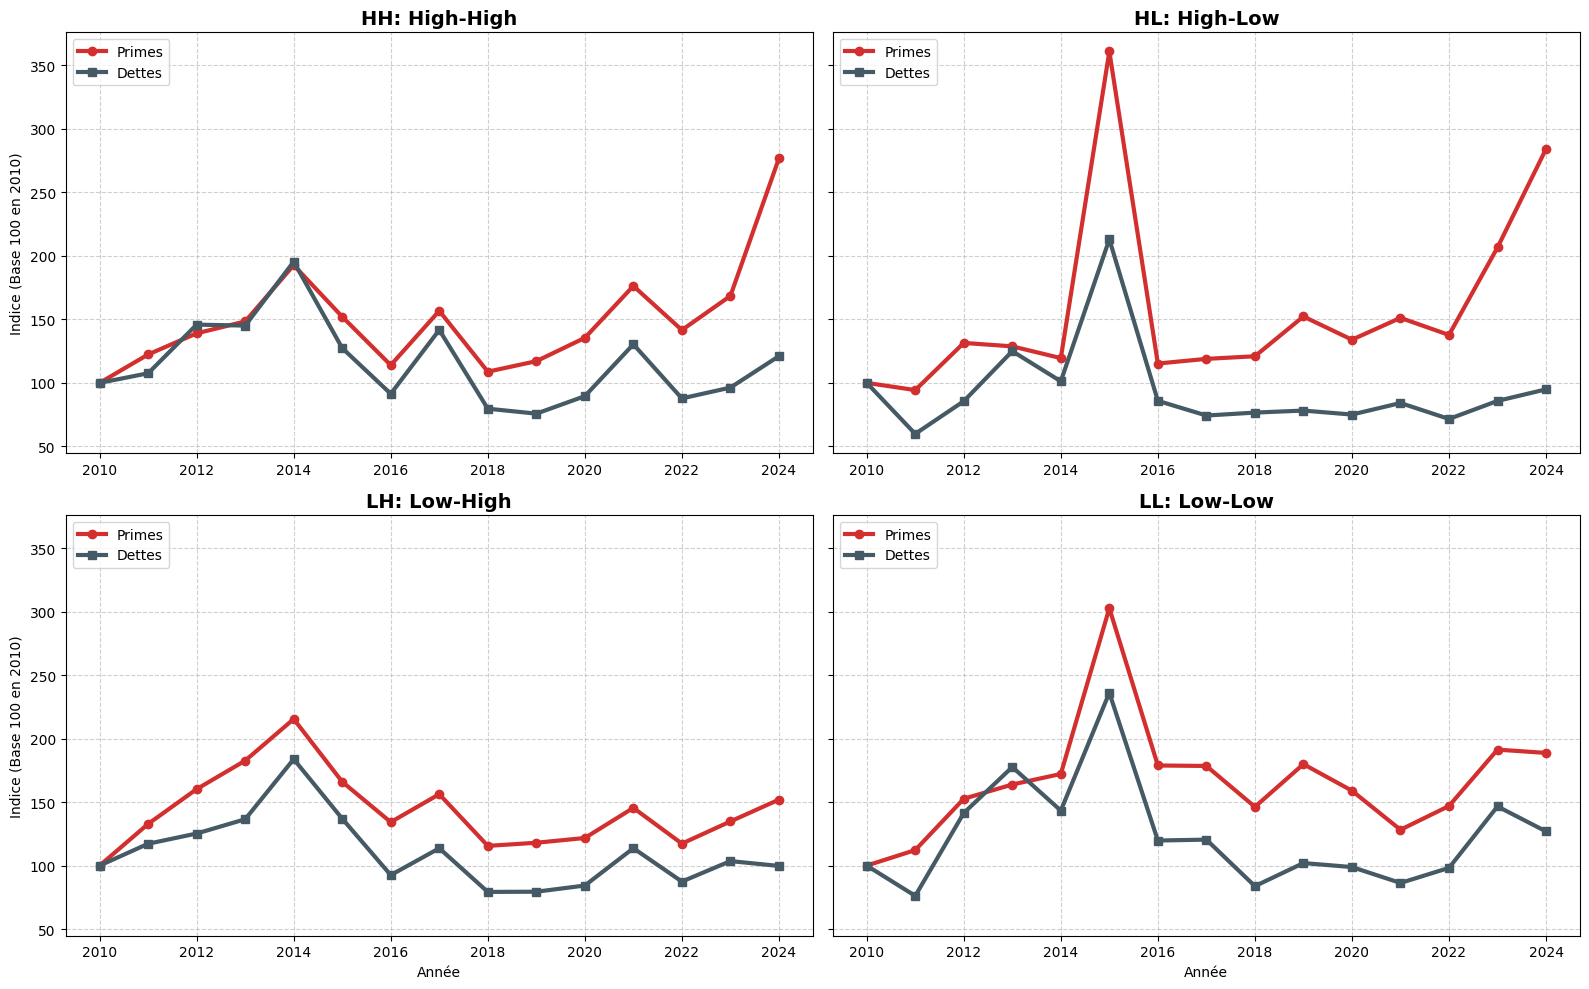

In [182]:
df_trends = comptes_final_plot.merge(
    cluster_bi_1[["code_geo", "cluster_type"]],
    left_on="code_geo_from_siren",
    right_on="code_geo",
)


def get_base_100_trends(df, cluster_name):
    subset = df[df["cluster_type"] == cluster_name]
    base_year = 2010

    yearly_medians = subset.groupby("annee").agg(
        {"primes": "median", "dettes": "median"}
    )

    base_primes = yearly_medians.loc[base_year, "primes"]
    base_depenses = yearly_medians.loc[base_year, "dettes"]

    yearly_medians["Primes (Indice)"] = (yearly_medians["primes"] / base_primes) * 100
    yearly_medians["Dettes (Indice)"] = (yearly_medians["dettes"] / base_depenses) * 100

    return yearly_medians


quadrants = ["Hotspot (HH)", "Outlier (HL)", "Outlier (LH)", "Coldspot (LL)"]
titles = ["HH: High-High", "HL: High-Low", "LH: Low-High", "LL: Low-Low"]

fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharey=True)
axes = axes.flatten()

for i, cluster in enumerate(quadrants):
    stats = get_base_100_trends(df_trends, cluster)
    ax = axes[i]

    # Plot Primes
    ax.plot(
        stats.index,
        stats["Primes (Indice)"],
        marker="o",
        linewidth=3,
        color="#D32F2F",
        label="Primes",
    )

    # Plot Dettes
    ax.plot(
        stats.index,
        stats["Dettes (Indice)"],
        marker="s",
        linewidth=3,
        color="#455A64",
        label="Dettes",
    )

    ax.set_title(titles[i], fontsize=14, fontweight="bold")
    ax.grid(True, linestyle="--", alpha=0.6)

    if i % 2 == 0:
        ax.set_ylabel("Indice (Base 100 en 2010)")

    if i >= 2:
        ax.set_xlabel("Année")

    ax.legend(loc="upper left")

plt.tight_layout()
plt.show()

## TASK - 1: Stripe Communes


Les "Cat-Nat stripes" mais avec le nombre de commune touchées plutôt que le nombre de Cat-Nat


In [ ]:
# 1. Create a temporary year column for deduplication
details_par_catnat["year"] = details_par_catnat["date_debut_evenement"].dt.year

# Total occurrences
occur_total = (
    details_par_catnat.drop_duplicates(subset=["year", "code_geo"])
    .groupby("year")
    .size()
)

# Inondations
occur_inond = (
    details_par_catnat[details_par_catnat["nom_peril"] == "Inondations"]
    .drop_duplicates(subset=["year", "code_geo"])
    .groupby("year")
    .size()
)

# Sécheresse
occur_secheresse = (
    details_par_catnat[details_par_catnat["nom_peril"] == "Sécheresse"]
    .drop_duplicates(subset=["year", "code_geo"])
    .groupby("year")
    .size()
)

annual_counts = occur_total.loc[:2025]
annual_counts_inond = occur_inond.loc[:2025]
annual_counts_secheresse = occur_secheresse.loc[:2025]

annual_counts_inond.index = pd.to_datetime(
    annual_counts_inond.index.astype(str) + "-12-31"
)
annual_counts_secheresse.index = pd.to_datetime(
    annual_counts_secheresse.index.astype(str) + "-12-31"
)

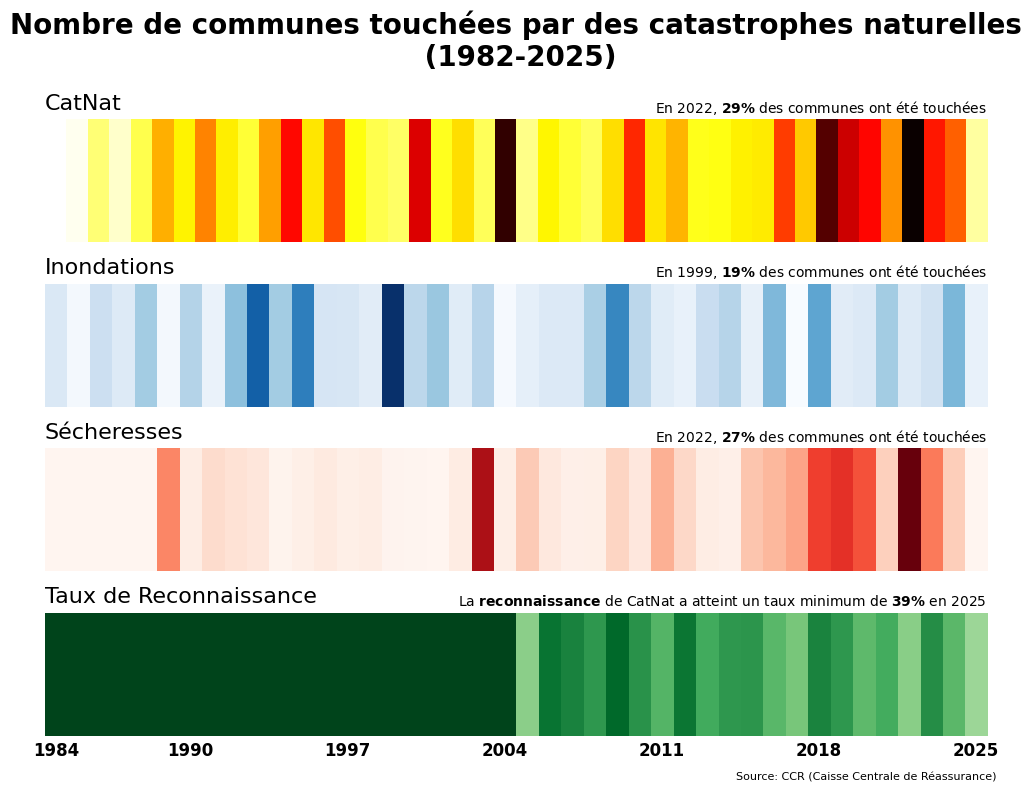

In [ ]:
# Recon
recon = details_par_catnat.copy()
recon = (
    (
        recon.groupby([details_par_catnat["date_arrete"], "libelle_avis"])
        .size()
        .unstack(fill_value=0)
    )
    .loc[:"2025"]
    .resample("YE")
    .sum()
)

recon["ratio_recon"] = (recon["Reconnue"] / recon.sum(axis=1)) * 100

all_years = recon.index

data_total = annual_counts.values.reshape(1, -1)
data_inond = annual_counts_inond.reindex(all_years, fill_value=0).values.reshape(1, -1)
data_sech = annual_counts_secheresse.reindex(all_years, fill_value=0).values.reshape(
    1, -1
)
data_recon = recon["ratio_recon"].loc[:"2025"].values.reshape(1, -1)


fig, axs = plt.subplots(nrows=4, figsize=(10, 8))

# CatNat
img = axs[0].imshow(data_total, cmap="hot_r", aspect="auto", interpolation="nearest")
axs[0].set_axis_off()

axs[0].set_title("CatNat", loc="left", pad=7.5, fontsize=16, color="black")

# Inondations
img = axs[1].imshow(data_inond, cmap="Blues", aspect="auto", interpolation="nearest")
axs[1].set_axis_off()

axs[1].set_title("Inondations", loc="left", pad=7.5, fontsize=16, color="black")

# Sécheresse
img = axs[2].imshow(data_sech, cmap="Reds", aspect="auto", interpolation="nearest")
axs[2].set_axis_off()

axs[2].set_title("Sécheresses", loc="left", pad=7.5, fontsize=16, color="black")

# Recon
img = axs[3].imshow(
    data_recon, cmap="Greens", aspect="auto", interpolation="nearest", vmin=0, vmax=100
)

axs[3].set_title(
    "Taux de Reconnaissance", loc="left", pad=7.5, fontsize=16, color="black"
)

# Axis
tick_indices = np.linspace(0, len(all_years) - 1, 7, dtype=int)

axs[3].set_xticks(tick_indices)
axs[3].set_xticklabels(
    [all_years.year[i] for i in tick_indices],
    fontsize=12,
    fontweight="bold",
    color="black",
)

axs[3].tick_params(axis="x", which="both", length=0)

for ax in axs:
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_yticks([])

# Titles and  Annotations
plt.suptitle(
    "Nombre de communes touchées par des catastrophes naturelles\n (1982-2025)",
    color="black",
    fontsize=20,
    fontweight="bold",
    y=0.99,
)

ratio = (annual_counts.max() / communes_geo.shape[0]) * 100
label = rf"En 2022, $\bf{{{ratio:.0f}\%}}$ des communes ont été touchées"
axs[0].text(
    1,
    1.1,
    label,
    transform=axs[0].transAxes,
    ha="right",
    va="center",
    fontsize=10,
    color="black",
)

ratio = (annual_counts_inond.max() / communes_geo.shape[0]) * 100
label = rf"En 1999, $\bf{{{ratio:.0f}\%}}$ des communes ont été touchées"
axs[1].text(
    1,
    1.1,
    label,
    transform=axs[1].transAxes,
    ha="right",
    va="center",
    fontsize=10,
    color="black",
)

ratio = (annual_counts_secheresse.max() / communes_geo.shape[0]) * 100
label = rf"En 2022, $\bf{{{ratio:.0f}\%}}$ des communes ont été touchées"
axs[2].text(
    1,
    1.1,
    label,
    transform=axs[2].transAxes,
    ha="right",
    va="center",
    fontsize=10,
    color="black",
)

axs[3].text(
    1,
    1.1,
    r"La $\bf{reconnaissance}$ de CatNat a atteint un taux minimum de $\bf{39\%}$ en 2025",
    transform=axs[3].transAxes,
    ha="right",
    va="center",
    fontsize=10,
    color="black",
)

plt.text(
    1.01,
    -0.375,
    source_text,
    ha="right",
    va="bottom",
    transform=axs[3].transAxes,
    fontsize=8,
    color="black",
)

plt.tight_layout()
"""
plt.savefig(
    "Evolution_CatNat_France_1982_2025.png",
    dpi=300,
    facecolor=fig.get_facecolor(),
    edgecolor="none",
    bbox_inches="tight",
    pad_inches=0.5,
)
"""

plt.show()


## TASK - 2: Moyenne mobile communes touchées


La part des communes qui a déjà été touchées par une cat nat (les moyennes mobiles sur 5 et 10 ans pour comparer ça serait pas mal)


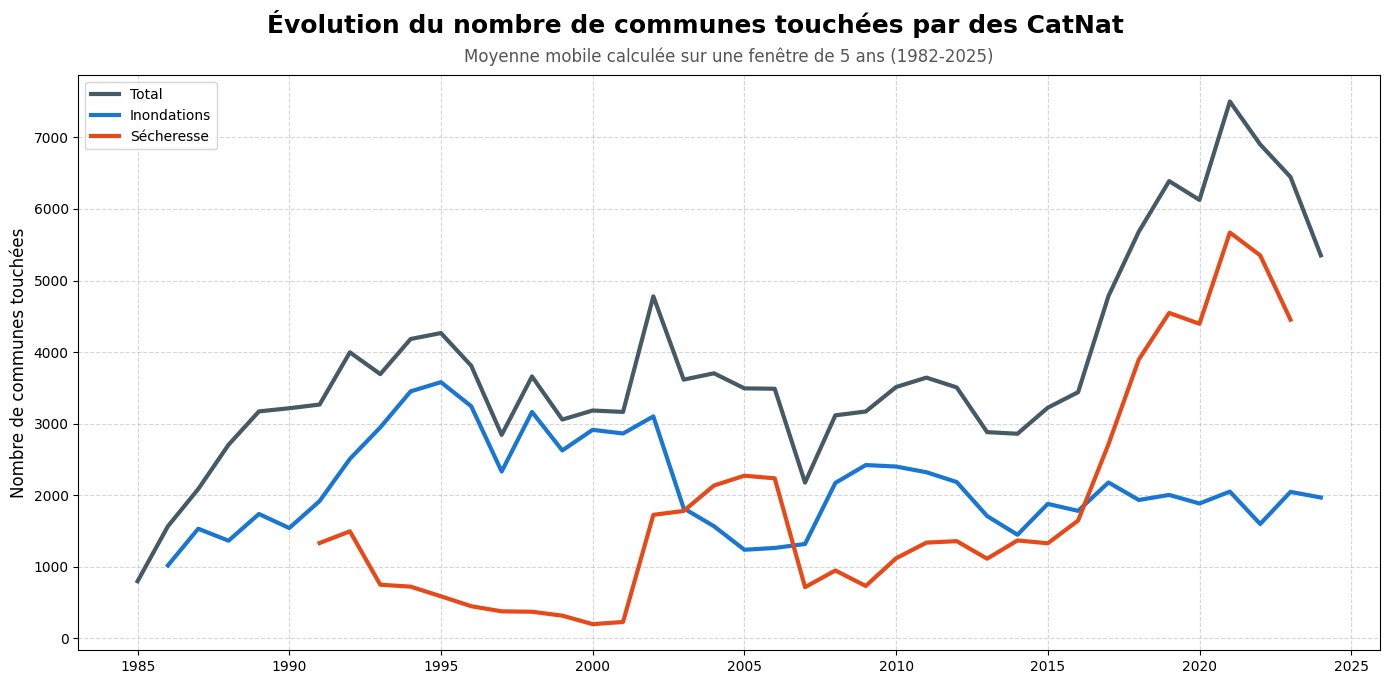

In [ ]:
for df in [annual_counts, annual_counts_inond, annual_counts_secheresse]:
    if not isinstance(df.index, pd.DatetimeIndex):
        df.index = pd.to_datetime(df.index.astype(str) + "-12-31")

window = 5
ma_total = annual_counts.rolling(window=window, center=True).mean()
ma_inond = annual_counts_inond.rolling(window=window, center=True).mean()
ma_sech = annual_counts_secheresse.rolling(window=window, center=True).mean()

plt.figure(figsize=(14, 7))

colors = {"Total": "#455A64", "Inondations": "#1976D2", "Sécheresse": "#E64A19"}

plt.plot(ma_total.index, ma_total, color=colors["Total"], linewidth=3, label="Total")
plt.plot(
    ma_inond.index,
    ma_inond,
    color=colors["Inondations"],
    linewidth=3,
    label="Inondations",
)
plt.plot(
    ma_sech.index, ma_sech, color=colors["Sécheresse"], linewidth=3, label="Sécheresse"
)

# Personnalisation
plt.suptitle(
    "Évolution du nombre de communes touchées par des CatNat",
    fontsize=18,
    fontweight="bold",
    y=0.97,
)

plt.title(
    f"Moyenne mobile calculée sur une fenêtre de {window} ans (1982-2025)",
    fontsize=12,
    color="#555555",
    pad=10,
)
plt.xlabel("", fontsize=12)
plt.ylabel("Nombre de communes touchées", fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.tight_layout()

plt.show()

## TASK - 3: Couverture PPRN par risques


Pour l'instant il y a un camembert sur la couverture PPRN des arrêtés reconnus, on aimerait l'avoir par risque (inondation, RGA et autres) si c'est possible


## TASK - 4: Communes catnat reconnu VS non reconnu (par an)


Nombre de communes touchées par un arrêté cat-nat reconnu VS non reconnu (par an) (+ idem mais comptabilisé en population)


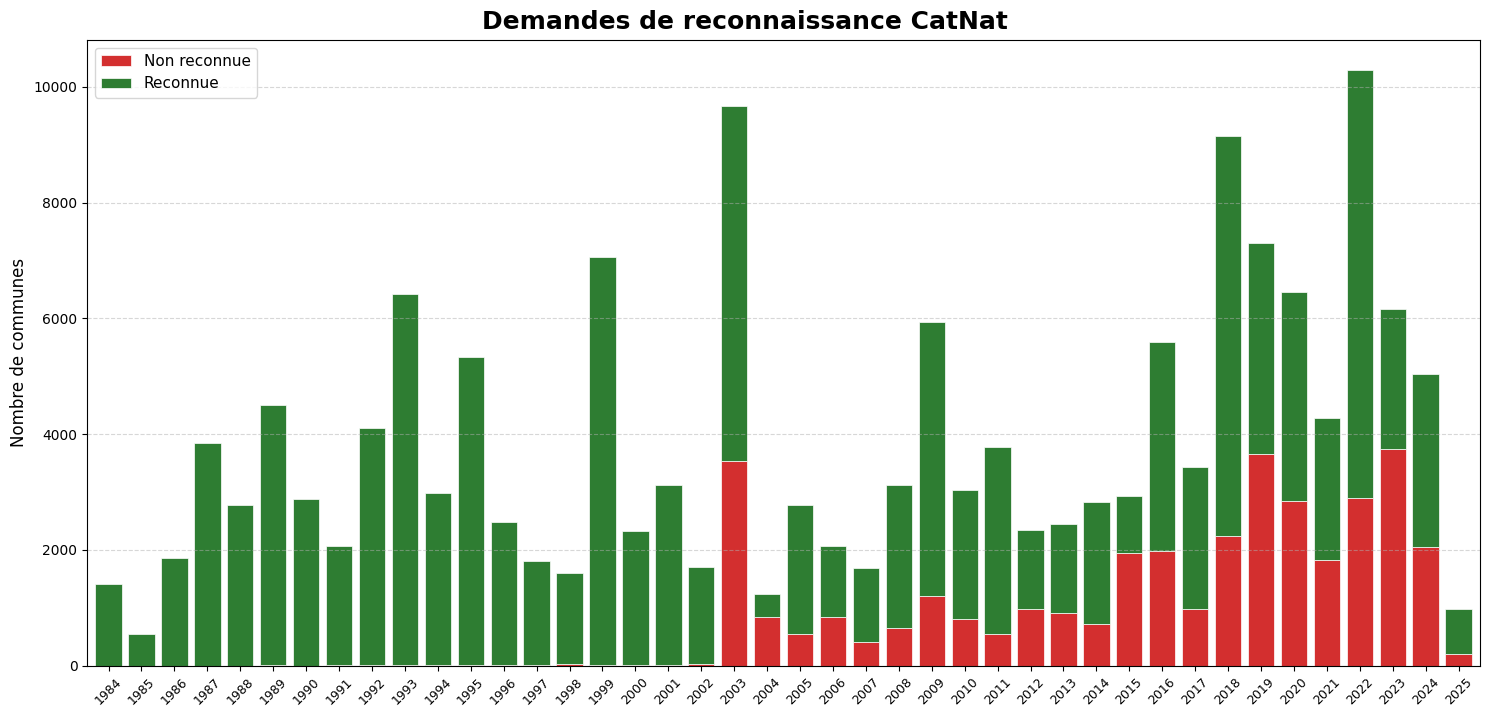

In [ ]:
details_par_catnat["year"] = details_par_catnat["date_debut_evenement"].dt.year
df_unique = details_par_catnat.drop_duplicates(subset=["year", "code_geo"])

evolution_statut = (
    df_unique.groupby(["year", "libelle_avis"]).size().unstack(fill_value=0)
)
evolution_statut = evolution_statut.loc[1984:2025]

colors = {
    "Reconnue": "#2E7D32",
    "Non reconnue": "#D32F2F",
}

current_colors = [colors.get(col, "#9E9E9E") for col in evolution_statut.columns]

ax = evolution_statut.plot(
    kind="bar",
    stacked=True,
    figsize=(15, 8),
    color=current_colors,
    width=0.8,
    edgecolor="white",
    linewidth=0.5,
)

plt.suptitle(
    "Demandes de reconnaissance CatNat", fontsize=18, fontweight="bold", y=0.92
)
plt.xlabel("", fontsize=12)
plt.ylabel("Nombre de communes", fontsize=12)

plt.xticks(rotation=45, fontsize=9)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.legend(title="", fontsize=11, loc="upper left")


plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## Final Task
